In [6]:
!pip install qutip
import qutip as qp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import Image
import seaborn as sns
from scipy import constants
from matplotlib.colors import TwoSlopeNorm
sns.set_style("whitegrid")

#Rabi Oscillations

Rabi oscillations are a quantum phenomenon that occurs when a two-level system, namely a qubit, is subjected to a time-varying harmonic driving force, leading to an actual oscillation of the qubit's energy, and with it, the occupation probability of the two levels.

The system of interest is a two-level atom irradiated by a light source. The overall Hamiltonian involved is therefore:


$$H_{tot} = H_{at} + H_{rad} + H_{int}$$


Where:

* $H_{at} = e_0 \vert 0 \rangle \langle 0 \vert + e_1 \vert 1 \rangle \langle 1 \vert$, with $e_0$ and $e_1$ being the two energy eigenvalues of the qubit, and $e_0 > e_1$ by convention. By defining $\omega_0 = \frac{e_0-e_1}{\hbar}$ and setting the energy $0$ halfway between the two levels, we can rewrite it as:
$$H_{at} = \frac{\hbar \omega_0}{2} \sigma_z$$
Where $\sigma_z$ is the Pauli matrix: $\sigma_z = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}$
In QuTiP we have: $\vert 0 \rangle = \begin{pmatrix} 1 \\ 0 \end{pmatrix}$ and $\vert 1 \rangle = \begin{pmatrix} 0 \\ 1 \end{pmatrix}$, hence: $\langle 0 \vert \sigma_z \vert 0 \rangle = 1$, $\langle 1 \vert \sigma_z \vert 1 \rangle = -1$.
Therefore, $\vert 0 \rangle$ will be the excited state with higher energy, while $\vert 1 \rangle$ will represent the lower energy state.
* $H_{rad} = \sum_{k, \sigma} \hbar \omega_{k}\bigl(a^{\dagger}_{k, \sigma}a_{k, \sigma}+\frac{1}{2} \bigr)$ is the Hamiltonian of the free quantized electromagnetic radiation, where the sum is extended over all wave vectors $\vec{k}$ and possible polarizations $\sigma$. To significantly simplify the calculations, we consider a single mode of the EM radiation with frequency $\omega \approx \omega_0$, so that:

$$H_{rad} = \hbar \omega \bigl(a^{\dagger}a+\frac{1}{2}\bigr)$$


* $H_{int}$ is given by the **Jaynes-Cummings Hamiltonian**, which, under the dipole, weak field, single-mode, and rotating wave approximations, takes the expression:

$$H_{int} = g a \sigma_+ + g^* a^{\dagger} \sigma_-$$



Where $g$ is a coupling constant between the field and the atom, and $\sigma_+$ and $\sigma_-$ are respectively given by: $\sigma_+ = \vert 0 \rangle \langle 1 \vert$, $\sigma_- = \vert 1 \rangle \langle 0 \vert$

## Semiclassical Case

Let us first consider a semiclassical case, in which we treat the EM radiation as classical.
To do this, we replace the annihilation operator $a$ within the interaction Hamiltonian with the complex value $\alpha$, which represents the complex amplitude of the electromagnetic wave, and the creation operator $a^{\dagger}$ with its complex conjugate $\alpha^*$. Thus, we obtain:


$$H_{int} = g\alpha \sigma_+ + g^* \alpha^* \sigma_-$$


From this, moving to the interaction picture and calculating the unitary evolution operator, we obtain for the state of the atom:


$$\vert{}\psi(t)\rangle = \left( \cos \left(\frac{\vert{}\alpha g\vert{} t}{\hbar} \right) - i\sin \left(\frac{\vert{}\alpha g\vert{} t}{\hbar} \right) \frac{\alpha g \sigma_+ + \alpha^* g^* \sigma_-}{\vert{}\alpha g\vert{}}\right) \vert{}\psi(0)\rangle$$


Assuming the initial state is the excited one, $\vert{}\psi(0)\rangle = \vert{}0\rangle$, the action of the operator simplifies (since $\sigma_+ \vert{}0\rangle = 0$ and $\sigma_- \vert{}0\rangle = \vert{}1\rangle$) and the time evolution reduces to:


$$\vert{}\psi(t)\rangle = \cos \left(\frac{\vert{}\alpha g\vert{} t}{\hbar} \right) \vert{}0\rangle - i\sin \left(\frac{\vert{}\alpha g\vert{} t}{\hbar} \right) e^{i \theta} \vert{}1\rangle$$

It can be seen that over time the state oscillates continuously between the excited state and the lower-energy state. The probability of finding the system in either of the two states will oscillate with a frequency double that of the sine argument, thereby defining the Rabi frequency of the system: $\Omega_{Rabi} = \frac{2\vert{}\alpha g\vert{}}{\hbar}$.

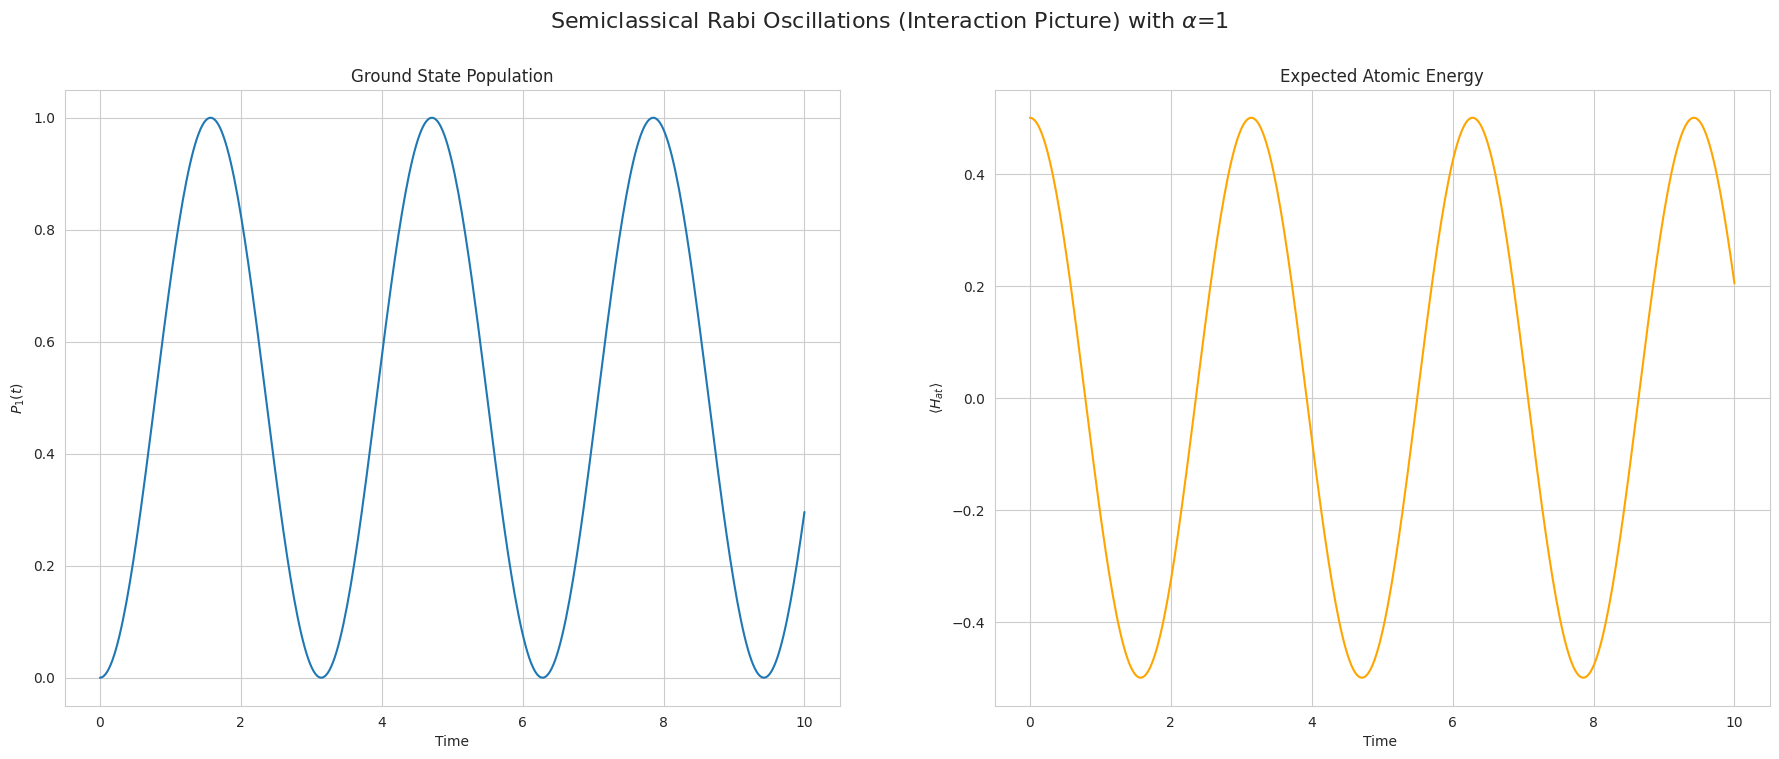

In [ ]:
Psi_0 = qp.basis(2, 0) #We start with the state |0>, corrisponding to the excited state in QuTip



##For the semplicity of the simulation we impose omega_0 and g = 1, we are gonna modify only the complex parameter \alpha
omega_0 = 1.0
alpha = 1
g=1.0

H_atom = (omega_0 / 2) * qp.sigmaz()

H = alpha * g * qp.sigmap() + np.conjugate(alpha)*np.conjugate(g)*qp.sigmam() #We define the Hamiltonian as above, using the interaction picture

T_list = np.linspace(0, 10, 400)

P_1 = qp.basis(2, 1)*qp.basis(2, 1).dag()
Results = qp.mesolve(H, Psi_0, T_list, e_ops=[P_1, H_atom])

plt.figure(figsize=(22, 8))
plt.suptitle(f"Semiclassical Rabi Oscillations (Interaction Picture) with $\\alpha$={alpha}", fontsize=16)

plt.subplot(121)
plt.plot(T_list, Results.expect[0])

plt.xlabel("Time")
plt.ylabel(r"$P_1 (t)$")
plt.title("Ground State Population")

plt.subplot(122)
plt.plot(T_list, Results.expect[1], color='orange')

plt.xlabel("Time ")
plt.ylabel(r"$\langle H_{at} \rangle$")
plt.title("Expected Atomic Energy")

plt.show()

We can further study how $P_1(t)$ change with the amplitude $\alpha$, to verify that $\Omega_{Rabi} \propto |\alpha|$

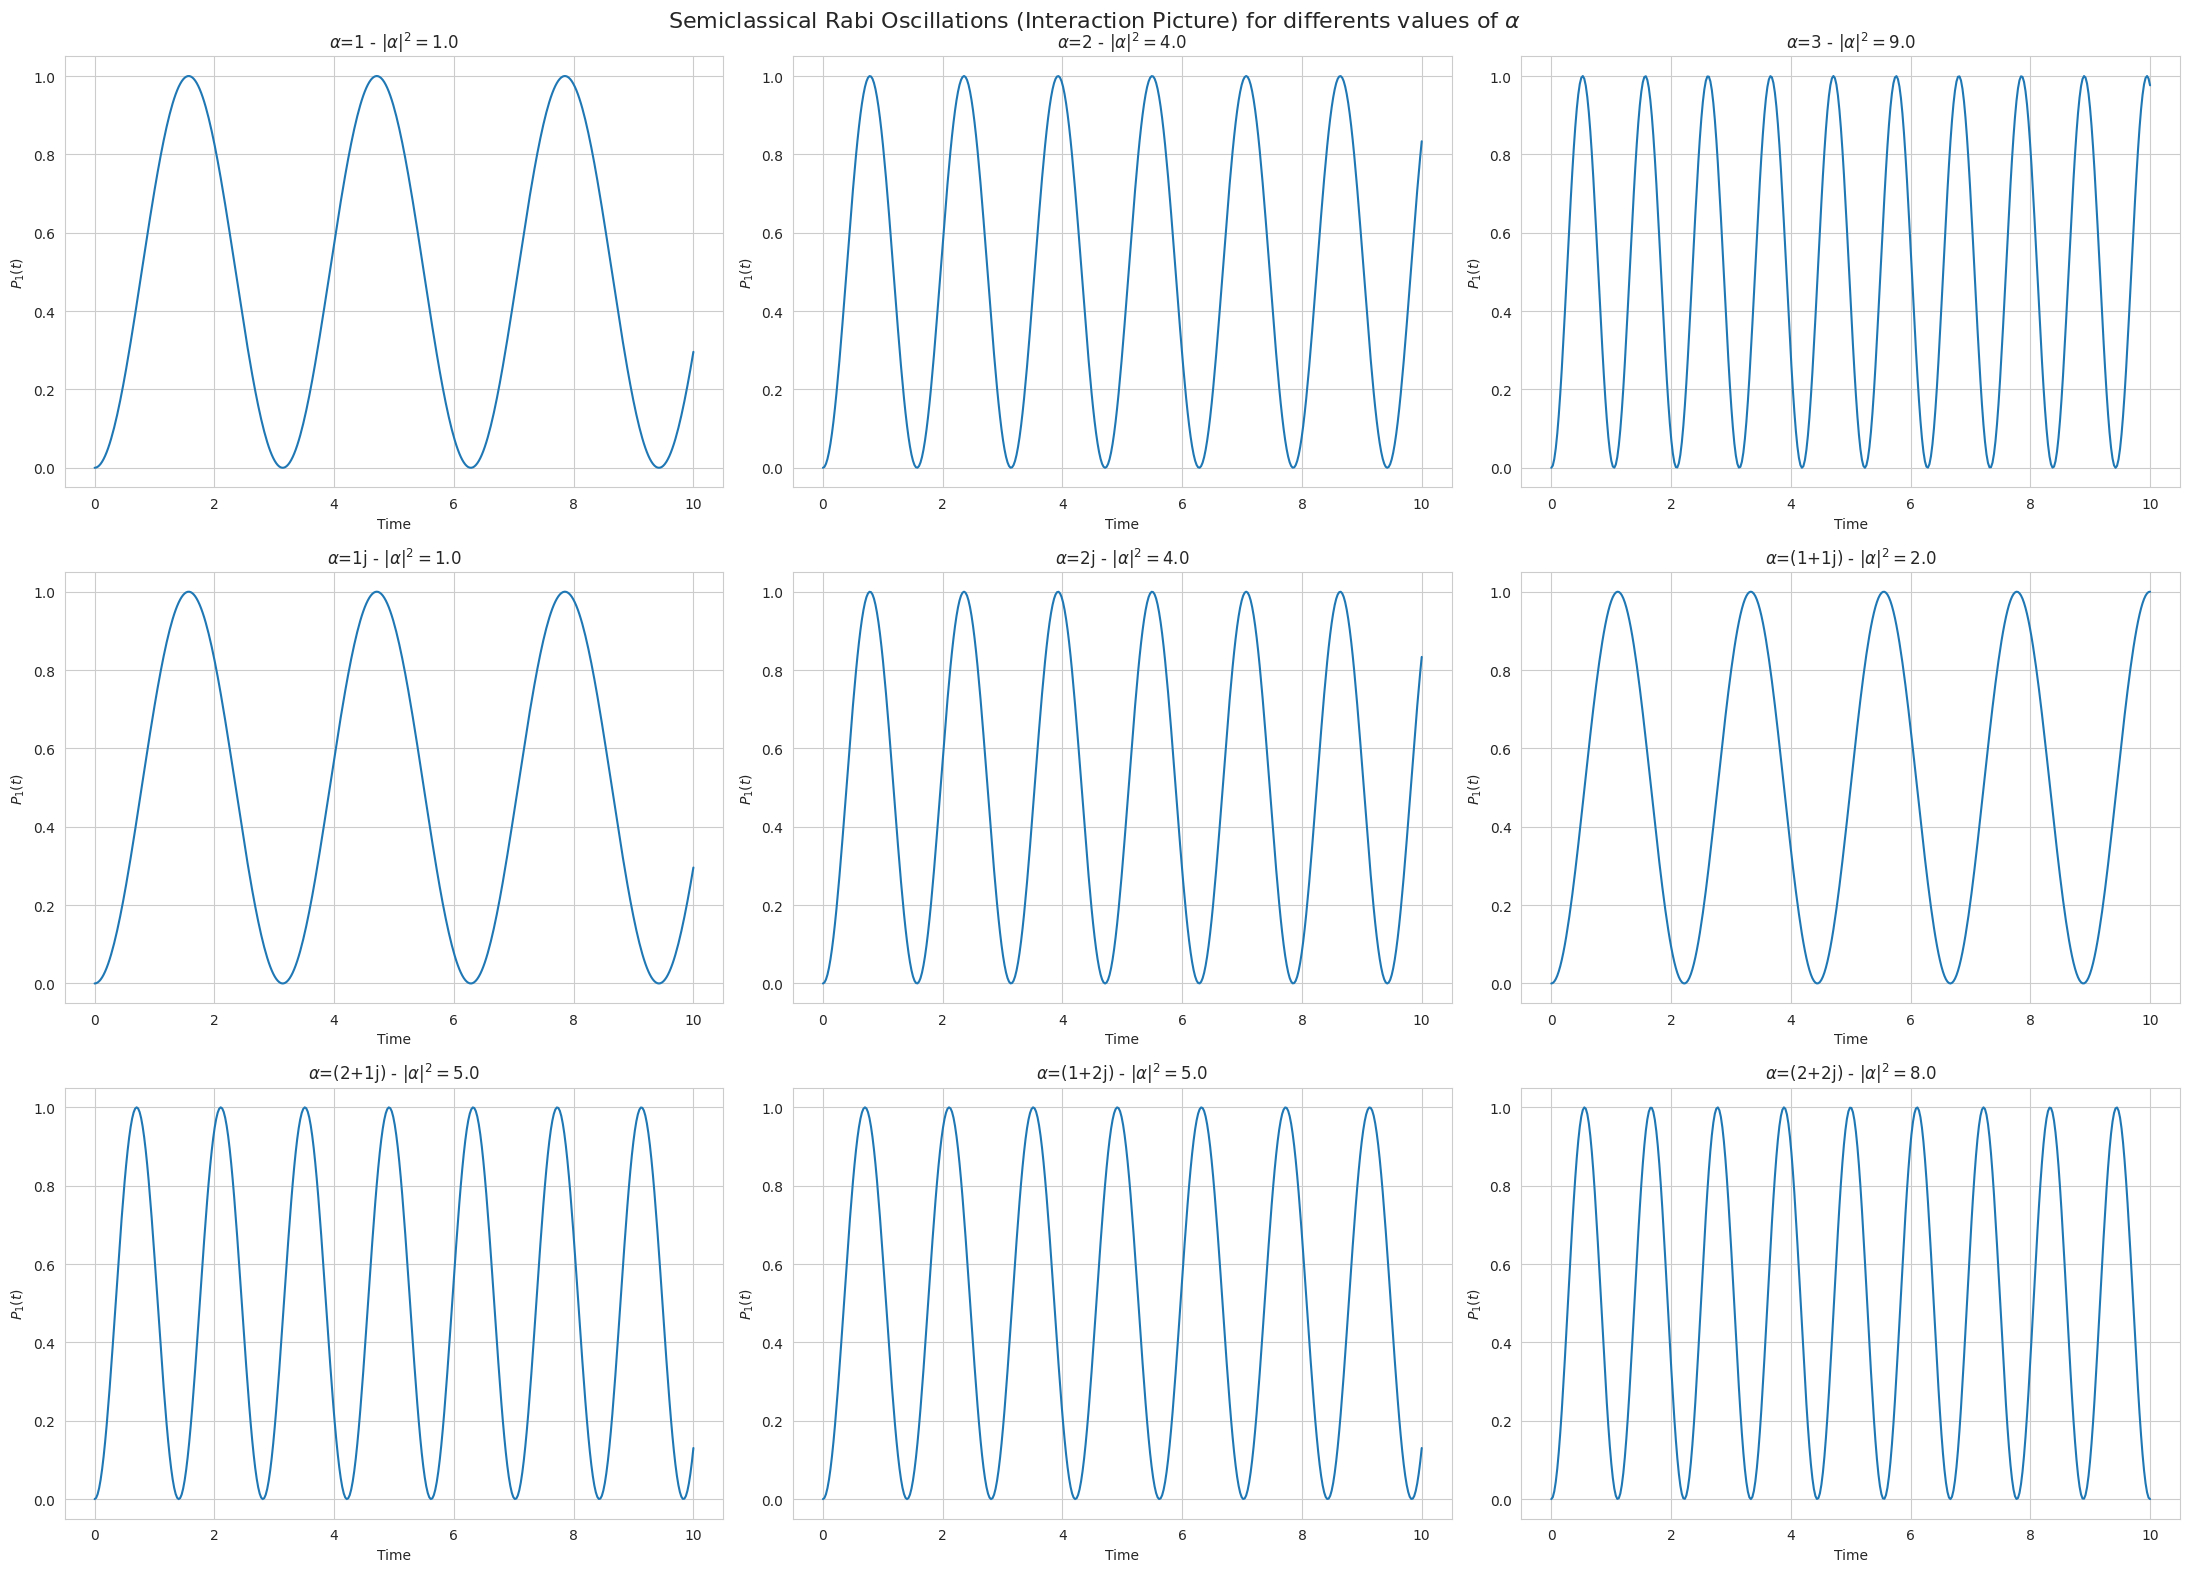

In [ ]:
Psi_0 = qp.basis(2, 0)
omega_0 = 1.0
g=1.0

T_list = np.linspace(0, 10, 400)
P_1 = qp.basis(2, 1)*qp.basis(2, 1).dag()


Alpha = [1, 2, 3, 1j, 2j, 1+1j, 2+1j, 1+2j, 2+2j] #Different Values of alpha

plt.figure(figsize=(22, 16))
plt.suptitle(f"Semiclassical Rabi Oscillations (Interaction Picture) for different values of $\\alpha$", fontsize=16)

i = 1
for alpha in Alpha:

  H = alpha * g * qp.sigmap() + np.conjugate(alpha)*np.conjugate(g)*qp.sigmam()


  Results = qp.mesolve(H, Psi_0, T_list, e_ops=[P_1])

  mod = np.abs(alpha)**2

  c = int('33' + str(i))
  i+=1

  plt.subplot(c)
  plt.plot(T_list, Results.expect[0])

  plt.xlabel("Time")
  plt.ylabel(r"$P_1 (t)$")
  plt.title(f"$\\alpha$={alpha} - $|\\alpha|^2 = {mod:.1f}$")

plt.tight_layout()
plt.show()

We can clearly see that for double $|\alpha|^2$, doubles the oscillations.

An interest thing happens for $\alpha = 0$:

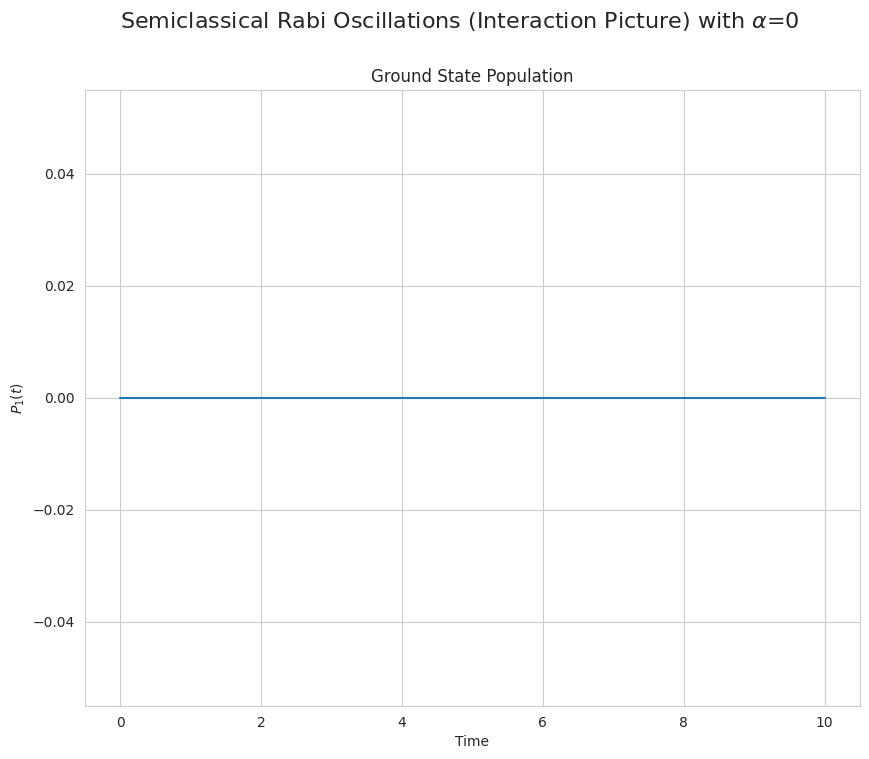

In [ ]:
Psi_0 = qp.basis(2, 0)
omega_0 = 1.0

alpha = 0

g=1.0


H = alpha * g * qp.sigmap() + np.conjugate(alpha)*np.conjugate(g)*qp.sigmam()

T_list = np.linspace(0, 10, 400)

P_1 = qp.basis(2, 1)*qp.basis(2, 1).dag()

Results = qp.mesolve(H, Psi_0, T_list, e_ops=[P_1])

plt.figure(figsize=(10, 8))
plt.suptitle(f"Semiclassical Rabi Oscillations (Interaction Picture) with $\\alpha$={alpha}", fontsize=16)

plt.plot(T_list, Results.expect[0])

plt.xlabel("Time")
plt.ylabel(r"$P_1 (t)$")
plt.title("Ground State Population")


plt.show()

No oscillations happens! This is wrong as we know that spontaneus emission exist.

##Quantum Case

We now consider a fully quantum case, in which the radiation is in a single Fock state $\vert{}n\rangle$, with $n \in \mathbb{N}$ representing the number of photons.Using the interaction picture and the Jaynes-Cummings Hamiltonian, and assuming the atom is initially in the excited state $\vert{}0\rangle$, the time evolution of the joint system is given by:$$\vert{}\psi(t)\rangle = U(t) \bigl(\vert{}0\rangle \otimes \vert{}n\rangle\bigr) = \cos\bigl( g t \sqrt{n+1}\bigr) \vert{}0\rangle \vert{}n\rangle - i \sin \bigl( gt \sqrt{n+1} \bigr) \vert{}1\rangle \vert{}n+1\rangle$$From this expression, we can see that the system remains in the excited state (with $n$ photons in the field) with a probability amplitude of $\cos\bigl( g t \sqrt{n+1}\bigr)$. Conversely, it transitions to the ground state (emitting a photon into the field, leading to the state $\vert{}n+1\rangle$) with a probability amplitude of $-i \sin \bigl( gt \sqrt{n+1} \bigr)$. \
In this case the Rabi frequency is then $Ω_{Rabi} = 2 g\sqrt{n+1}$

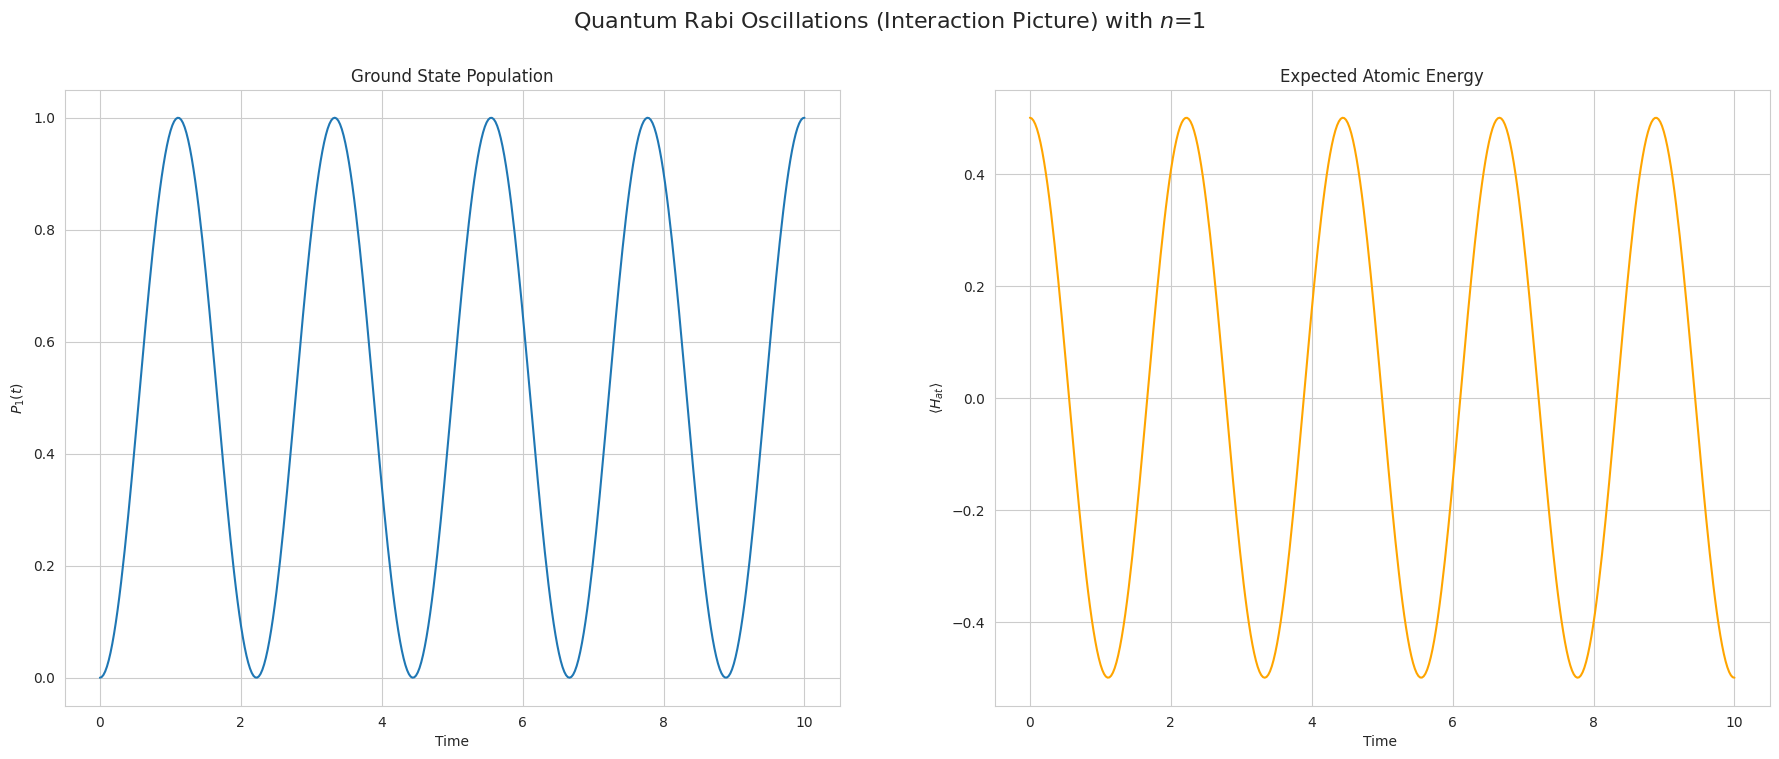

In [ ]:
N = 15 #Dimension of the Fock space, in a simulation it cannot be infinity as it should be, we need finite matricies
n = 1
Psi_at = qp.basis(2, 0) #We start with the state |0>, corrisponding to the excited state in QuTip
Psi_rad = qp.fock(N, n) #And with 1 photon, i.e. the state |1>

Psi_0 = qp.tensor(Psi_at, Psi_rad) #The joint initial state is then |0> x |1>


##For the semplicity of the simulation we impose omega_0 and g = 1
omega_0 = 1.0
g=1.0


H_atom = (omega_0 / 2) * qp.tensor(qp.sigmaz(), qp.qeye(N))

H =  g * qp.tensor(qp.sigmap(), qp.destroy(N)) + np.conjugate(g)*qp.tensor(qp.sigmam(), qp.create(N)) #We define the Hamiltonian as above, using the interaction picture

T_list = np.linspace(0, 10, 400)

P_1 = qp.tensor(qp.basis(2, 1)*qp.basis(2, 1).dag(), qp.qeye(N))

Results = qp.mesolve(H, Psi_0, T_list, e_ops=[P_1, H_atom])

plt.figure(figsize=(22, 8))
plt.suptitle(f"Quantum Rabi Oscillations (Interaction Picture) with $n$={n}", fontsize=16)

plt.subplot(121)
plt.plot(T_list, Results.expect[0])

plt.xlabel("Time")
plt.ylabel(r"$P_1 (t)$")
plt.title("Ground State Population")

plt.subplot(122)
plt.plot(T_list, Results.expect[1], color='orange')

plt.xlabel("Time ")
plt.ylabel(r"$\langle H_{at} \rangle$")
plt.title("Expected Atomic Energy")

plt.show()

We can try it with different numbers of photons:

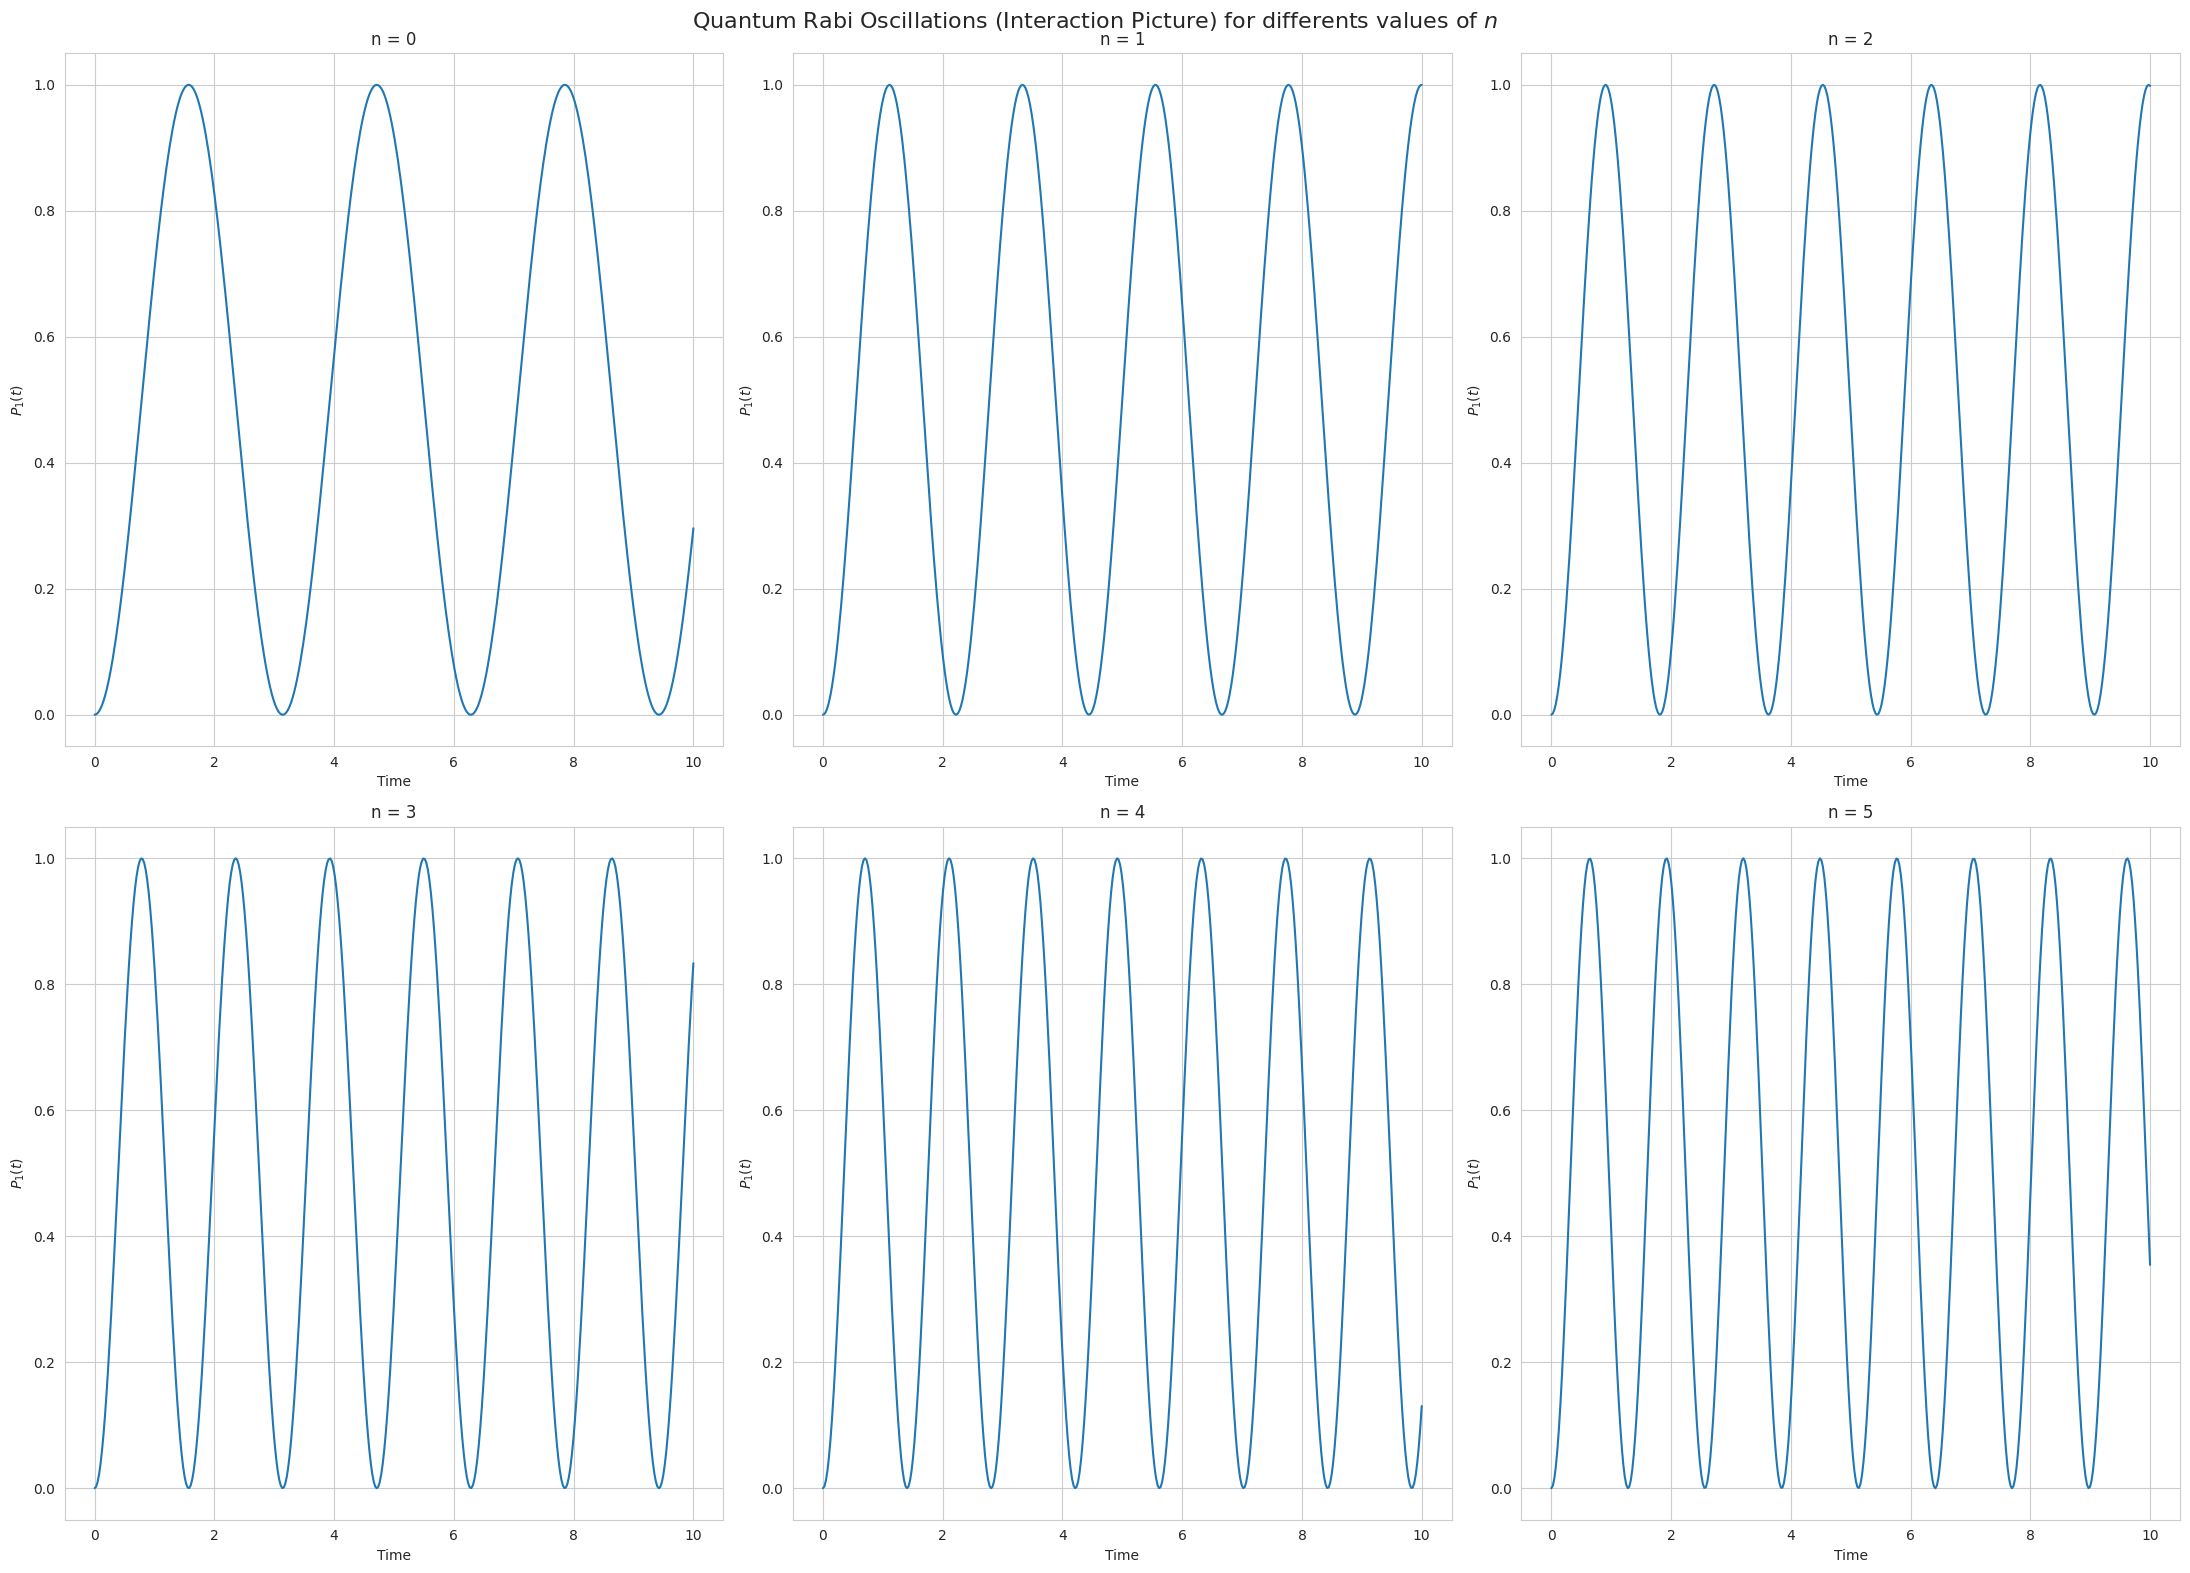

In [ ]:
N = 15 #Dimension of the Fock space, in a simulation it cannot be infinity as it should be, we need finite matricies

##For the semplicity of the simulation we impose omega_0 and g = 1
omega_0 = 1.0
g=1.0

Psi_at = qp.basis(2, 0) #We start with the state |0>, corrisponding to the excited state in QuTip

T_list = np.linspace(0, 10, 400)

H =  g * qp.tensor(qp.sigmap(), qp.destroy(N)) + np.conjugate(g)*qp.tensor(qp.sigmam(), qp.create(N)) #We define the Hamiltonian as above, using the interaction picture
P_1 = qp.tensor(qp.basis(2, 1)*qp.basis(2, 1).dag(), qp.qeye(N))

ns = [0, 1, 2, 3, 4, 5]

plt.figure(figsize=(22, 16))
plt.suptitle(f"Quantum Rabi Oscillations (Interaction Picture) for different values of $n$", fontsize=16)

i=1

for n in ns:
  Psi_rad = qp.fock(N, n)

  Psi_0 = qp.tensor(Psi_at, Psi_rad)


  Results = qp.mesolve(H, Psi_0, T_list, e_ops=[P_1])

  c= int('23' + str(i))
  i+=1

  plt.subplot(c)
  plt.plot(T_list, Results.expect[0])

  plt.xlabel("Time")
  plt.ylabel(r"$P_1 (t)$")
  plt.title(f"n = {n}")

plt.tight_layout()
plt.show()

From these plots, we can observe two main phenomena:
* Frequency dependence on photon number: Increasing the number of photons $n$ increases the oscillation frequency of $P_1(t)$. In particular, passing from $n=0$ (where $\sqrt{n+1} = 1$) to $n=3$ (where $\sqrt{n+1} = 2$) exactly doubles the Rabi frequency, perfectly matching the analytical prediction.
* Vacuum Rabi oscillations: Even when there are no photons in the cavity (i.e., when $n=0$), oscillations still occur. This is in stark contrast to the semiclassical case, where a zero-amplitude field implies no interaction, and demonstrates the purely quantum phenomenon of spontaneous emission driven by vacuum fluctuations.



#Quantum States of Radiation

##Fock States

The first states of radiation that come to mind are Fock states, which are the eigenstates of the number operator $\hat{n} = a^{\dagger}a$, namely:$$\hat{n} \vert{}n\rangle = n \vert{}n\rangle$$Where $n$ represents the number of photons (i.e. the excitations of a single mode of the electromagnetic field).

It can be shown that the Wigner function of a Fock state $|n⟩$ corresponds to a Laguerre polynomial with:


*   Exactly $n$ zeros, which appear as concentric nodal rings.
*   A positive peak for $\alpha = 0$ if $n$ is even, otherwise, if $n$ is odd, at $\alpha=0$ it shows a negative well.


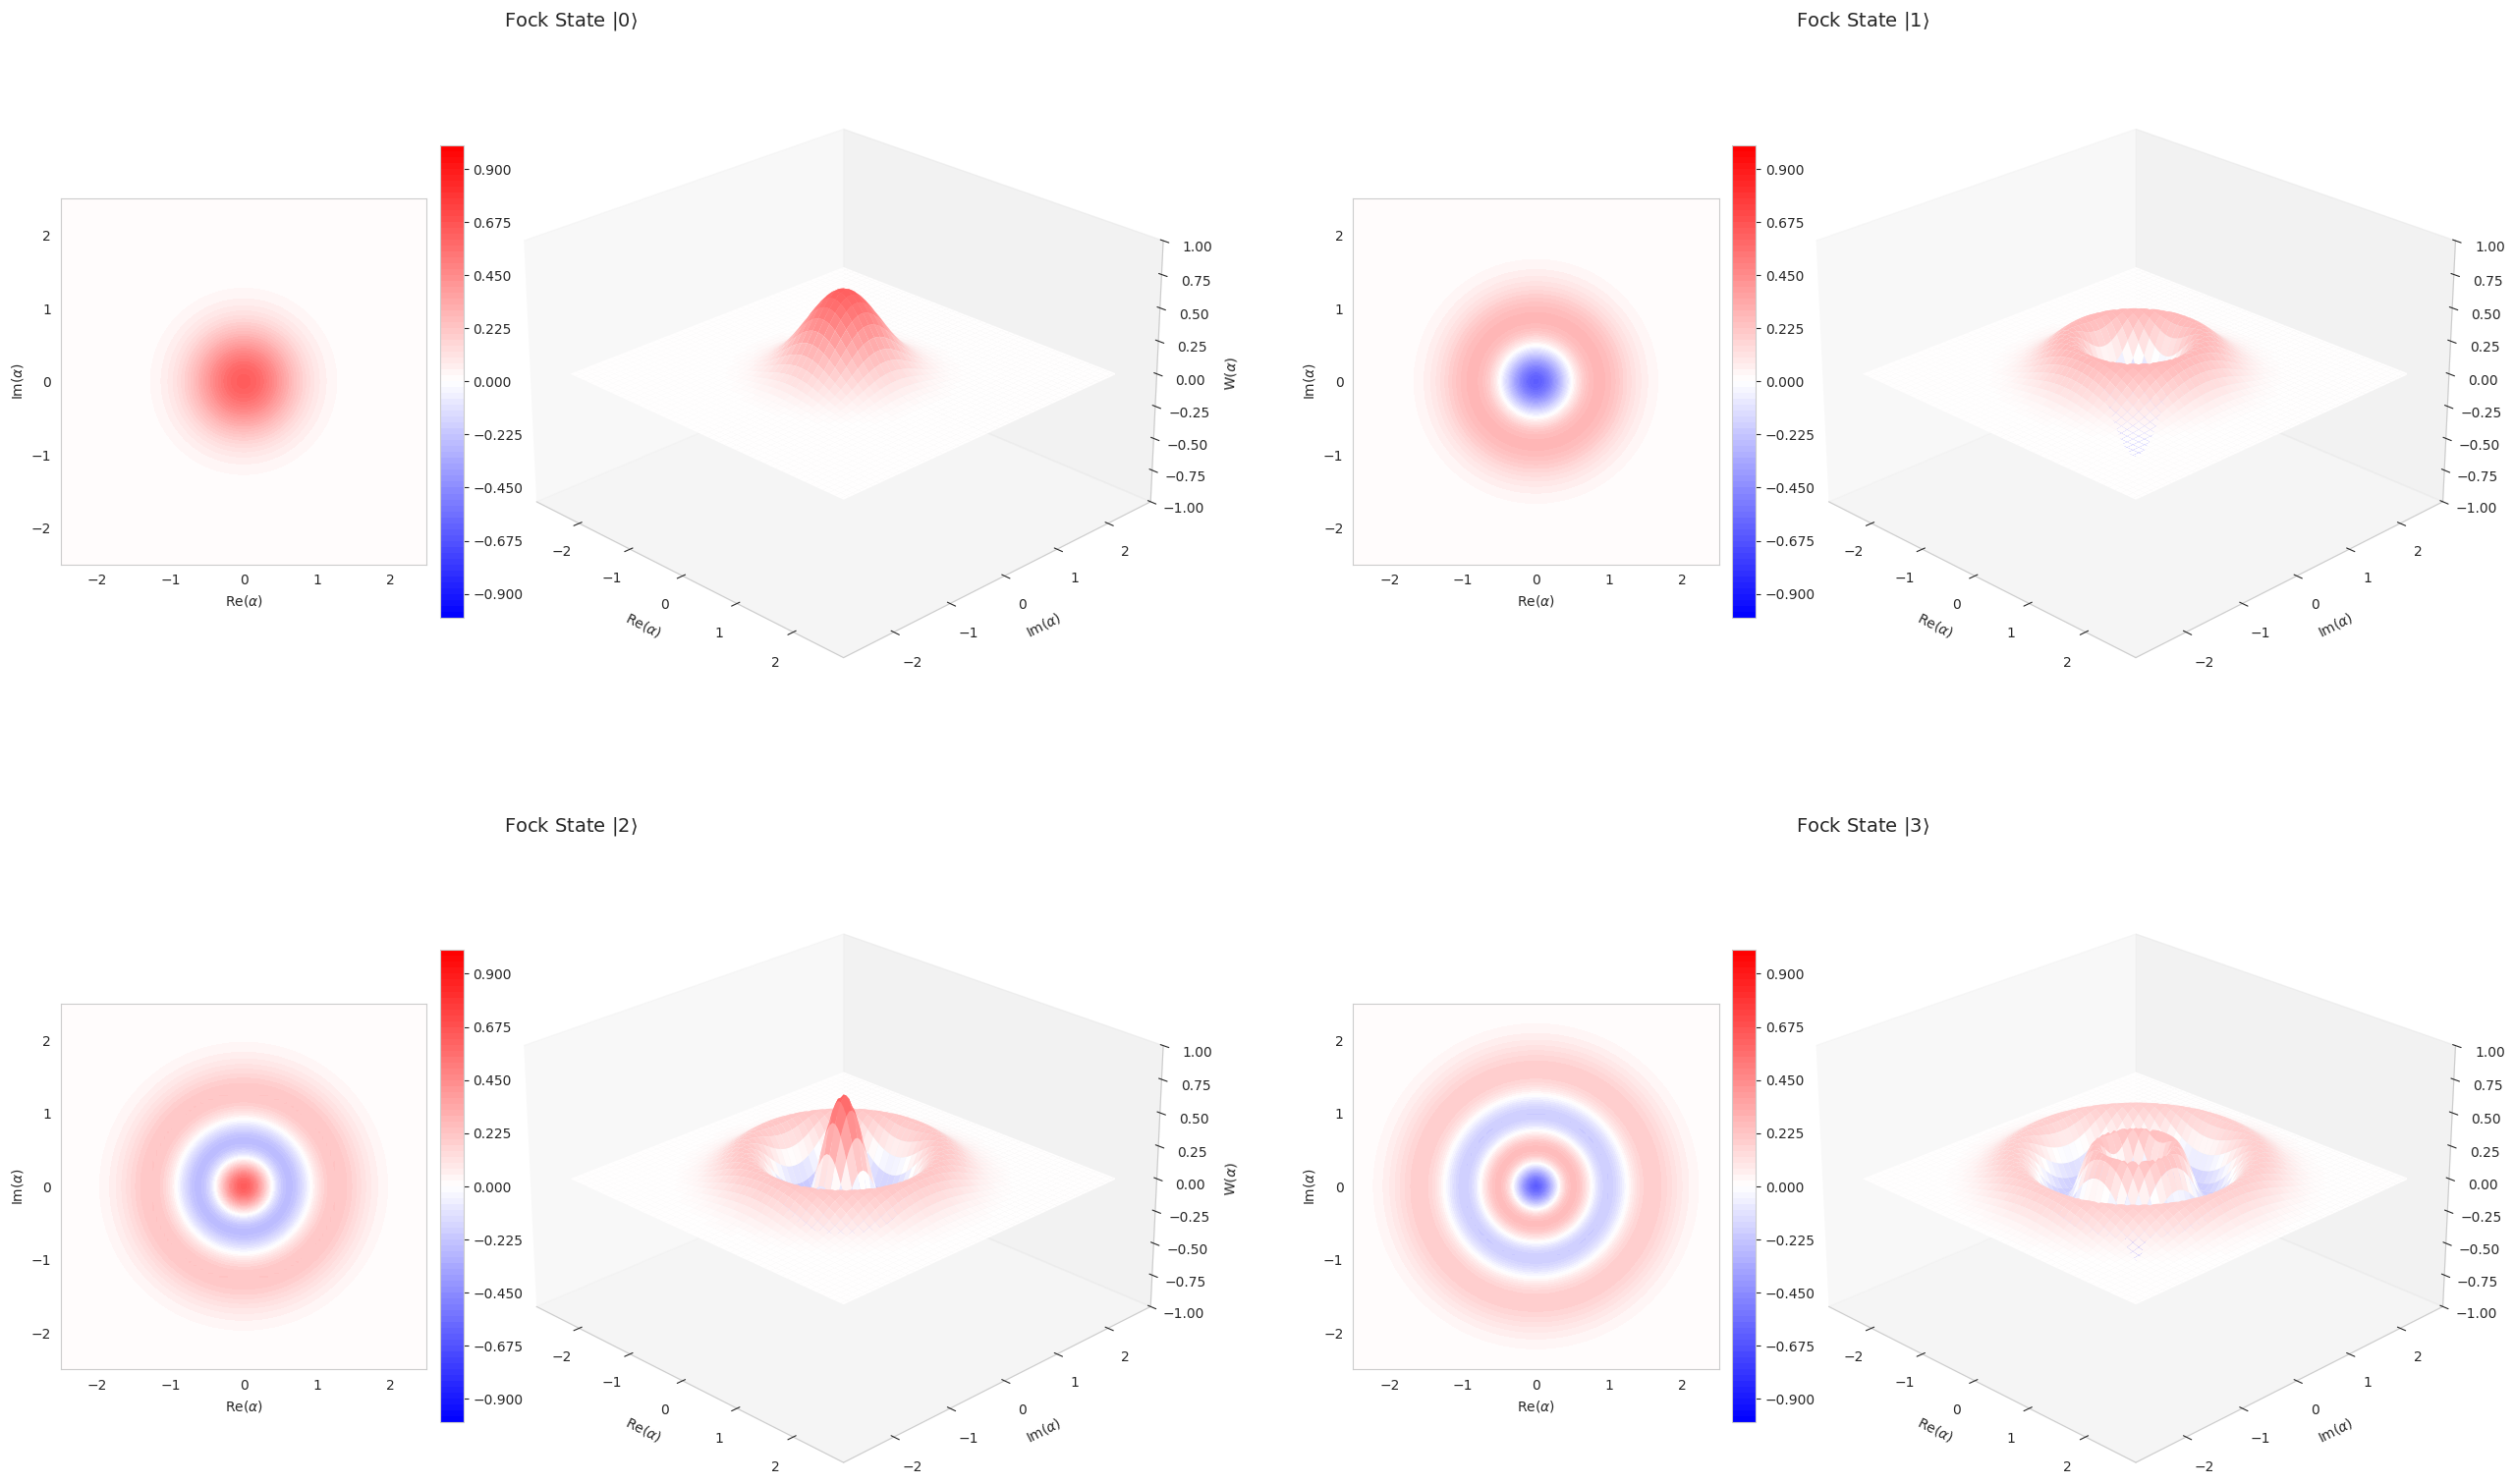

In [2]:
N=5

fig = plt.figure(figsize=(27, 16))

subfigs = fig.subfigures(2, 2, wspace=-0.05, hspace=0.05)

levels = np.linspace(-1, 1, 81)
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

xvec = np.linspace(-2.5, 2.5, 100)
pvec = np.linspace(-2.5, 2.5, 100)
X, Y = np.meshgrid(xvec, pvec)


for i, subfig in enumerate(subfigs.flat):
  Psi = qp.fock(N, i)

  W = qp.wigner(Psi, xvec, pvec, g=2)


  subfig.suptitle(rf"Fock State $ |{i} \rangle $", fontsize=14)

  sub = subfig.add_gridspec(1, 2,width_ratios=[1, 1.25], wspace=0.1)

  ax1 = subfig.add_subplot(sub[0, 0], aspect='equal')
  cont = ax1.contourf(xvec, pvec, W, levels=levels, cmap="bwr", norm = norm)
  subfig.colorbar(cont, ax=ax1, shrink=0.8, aspect=20, pad=0.03)

  ax1.set_xlabel(r'Re($\alpha$)')
  ax1.set_ylabel(r'Im($\alpha$)')


  ax2 = subfig.add_subplot(sub[0, 1], projection='3d')

  surf = ax2.plot_surface(X, Y, W, cmap ="bwr", linewidth = 0, norm=norm, antialiased=True , rstride=2, cstride=2)

  ax2.set_xlabel(r'Re($\alpha$)')
  ax2.set_ylabel(r'Im($\alpha$)')
  ax2.set_zlabel(r'W($\alpha$)')

  ax2.set_zlim3d(-1, 1)
  ax2.grid(False)
  ax2.set_box_aspect((1, 1, 0.65), zoom=1.2)
  ax2.view_init(elev=25, azim=-45)


plt.show()

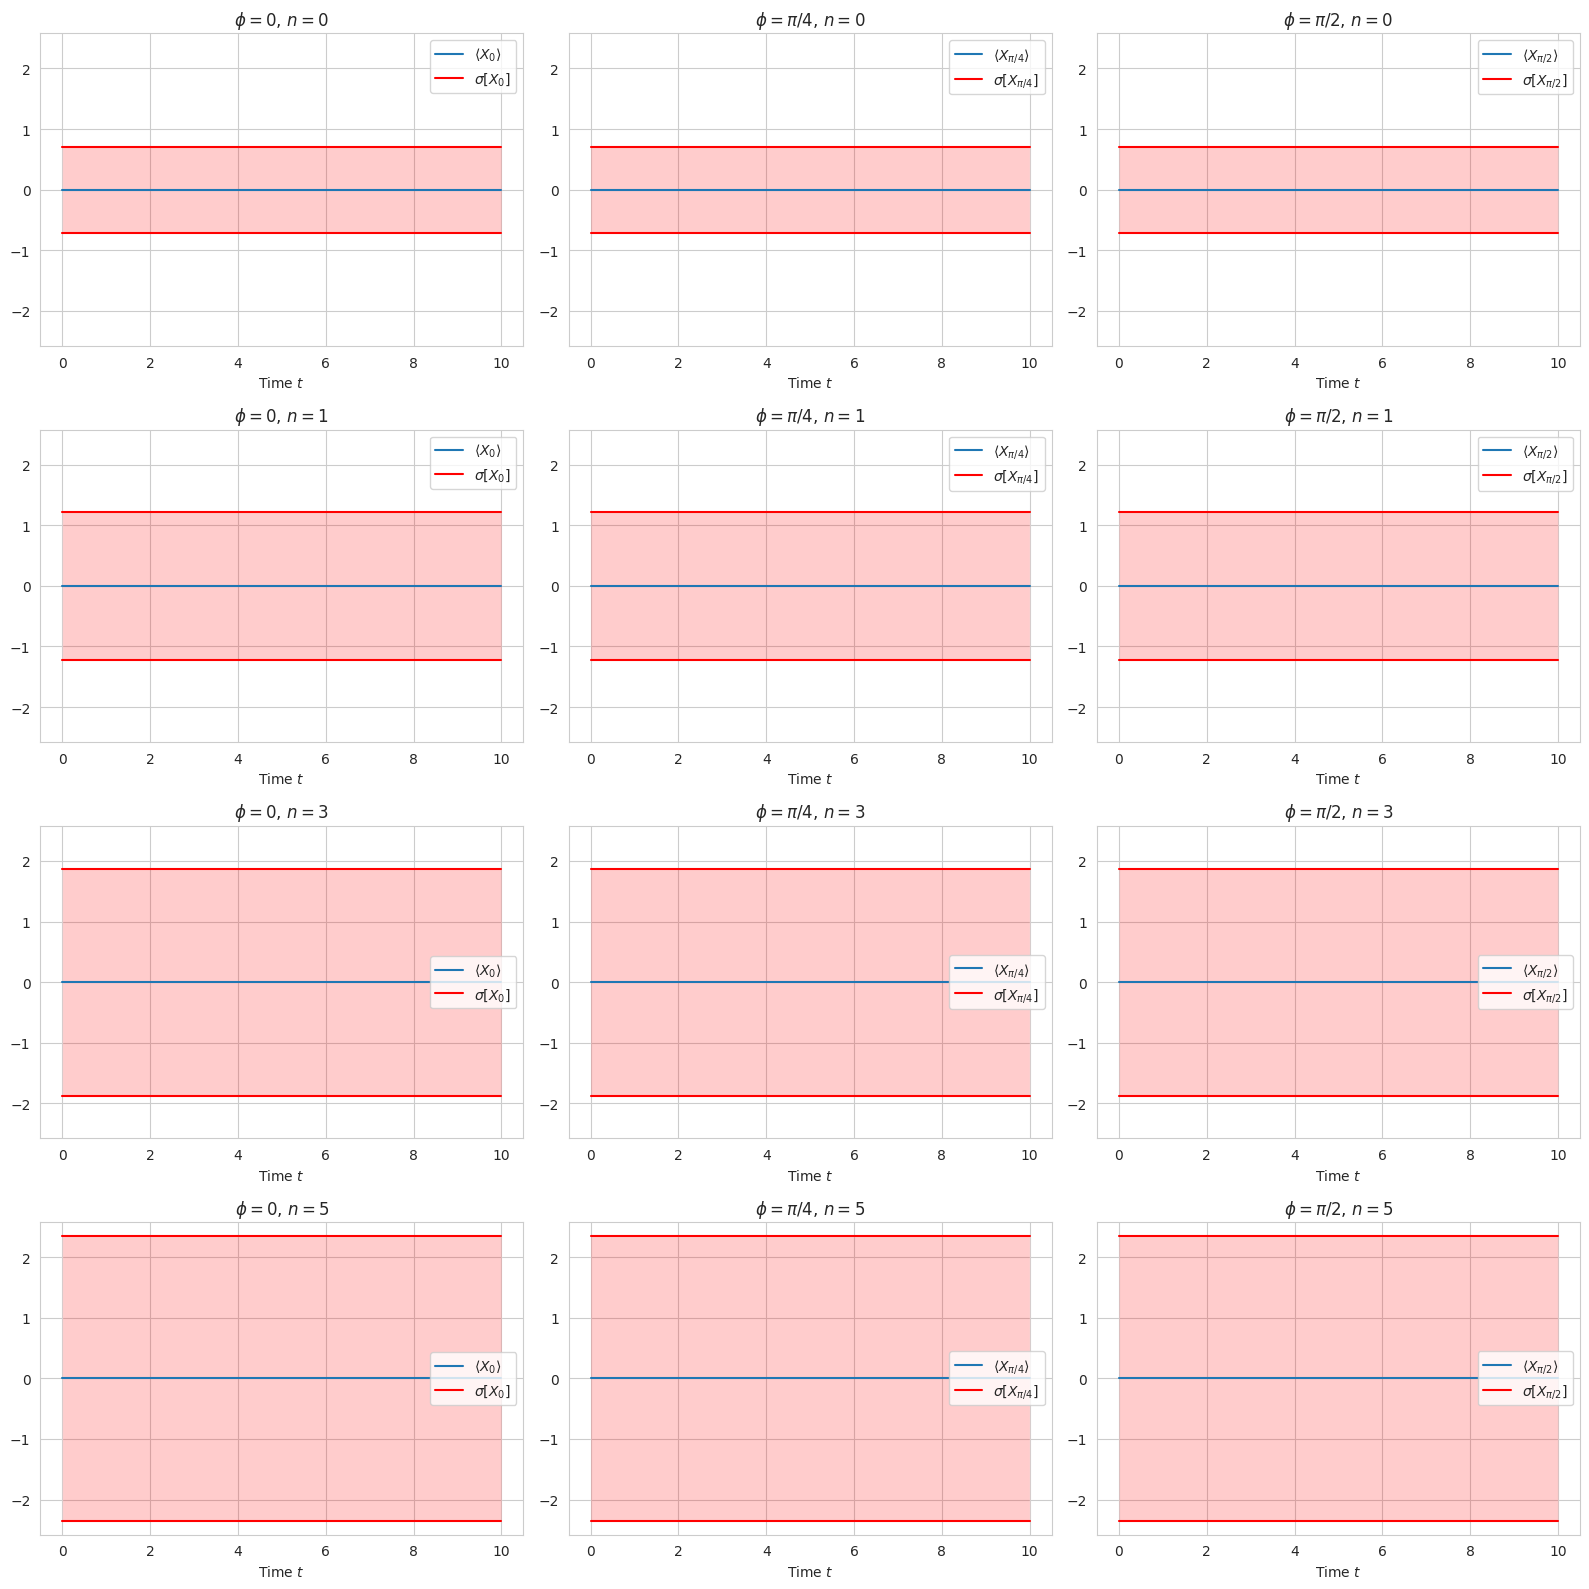

In [75]:
N=10
H_free = qp.create(N)*qp.destroy(N) + 1/2


ns = [0, 1, 3, 5]
Phis = [0, np.pi/4, np.pi/2]
Angles = ["0", r"{\pi/4}" ,r"{\pi/2}"]

plt.figure(figsize=(16, 16))

T=np.linspace(0, 10, 1000)

X_AVG = np.zeros((len(ns), len(Phis), len(T)))
DEVX = np.zeros((len(ns), len(Phis), len(T)))

c = 1

for j, n in enumerate(ns):
  for i, Phi in enumerate(Phis):



    X_phi = (qp.create(N)*np.exp(Phi*1j)+qp.destroy(N)*np.exp(-Phi*1j))/(np.sqrt(2))
    X_phi_sq = X_phi**2

    Psi_0 = qp.fock(N, n) #Stato iniziale |1>


    Results = qp.mesolve(H_free, Psi_0, T, e_ops=[X_phi, X_phi_sq])

    X_avg = Results.expect[0]
    X_avg_sq = Results.expect[1]
    VarX = Results.expect[1] - Results.expect[0]**2
    DevStdX = np.sqrt(VarX)

    X_AVG[j, i] = X_avg
    DEVX[j, i] = DevStdX



Xmax = np.maximum((X_AVG + DEVX).max(), (X_AVG - DEVX).max())

if(Xmax > 0):
  Xmax*=1.1
if(Xmax < 0):
  Xmax*=0.9


Xmin = np.minimum((X_AVG + DEVX).min(), (X_AVG - DEVX).min())

if(Xmin > 0):
  Xmin*=0.9
if(Xmin < 0):
  Xmin*=1.1

for j in range(len(ns)):
  for i in range(len(Phis)):
    plt.subplot(len(ns), len(Phis), c)
    c+=1
    plt.title(rf"$\phi = {Angles[i]:s}$, $n = ${ns[j]}")

    plt.plot(T, X_AVG[j, i], label=rf"$ \langle X_{Angles[i]:s} \rangle $")
    plt.plot(T, X_AVG[j, i] + DEVX[j, i], label=rf"$\sigma [X_{Angles[i]:s}]$", color='red')
    plt.plot(T, X_AVG[j, i] - DEVX[j, i], color='red')

    plt.fill_between(T, X_AVG[j, i] - DEVX[j, i], X_AVG[j, i] + DEVX[j, i], facecolor='red', alpha=0.2)

    plt.xlabel(r"Time $t$")

    plt.ylim(Xmin, Xmax)
    plt.legend()



plt.tight_layout()
plt.show()

##Coeherent States

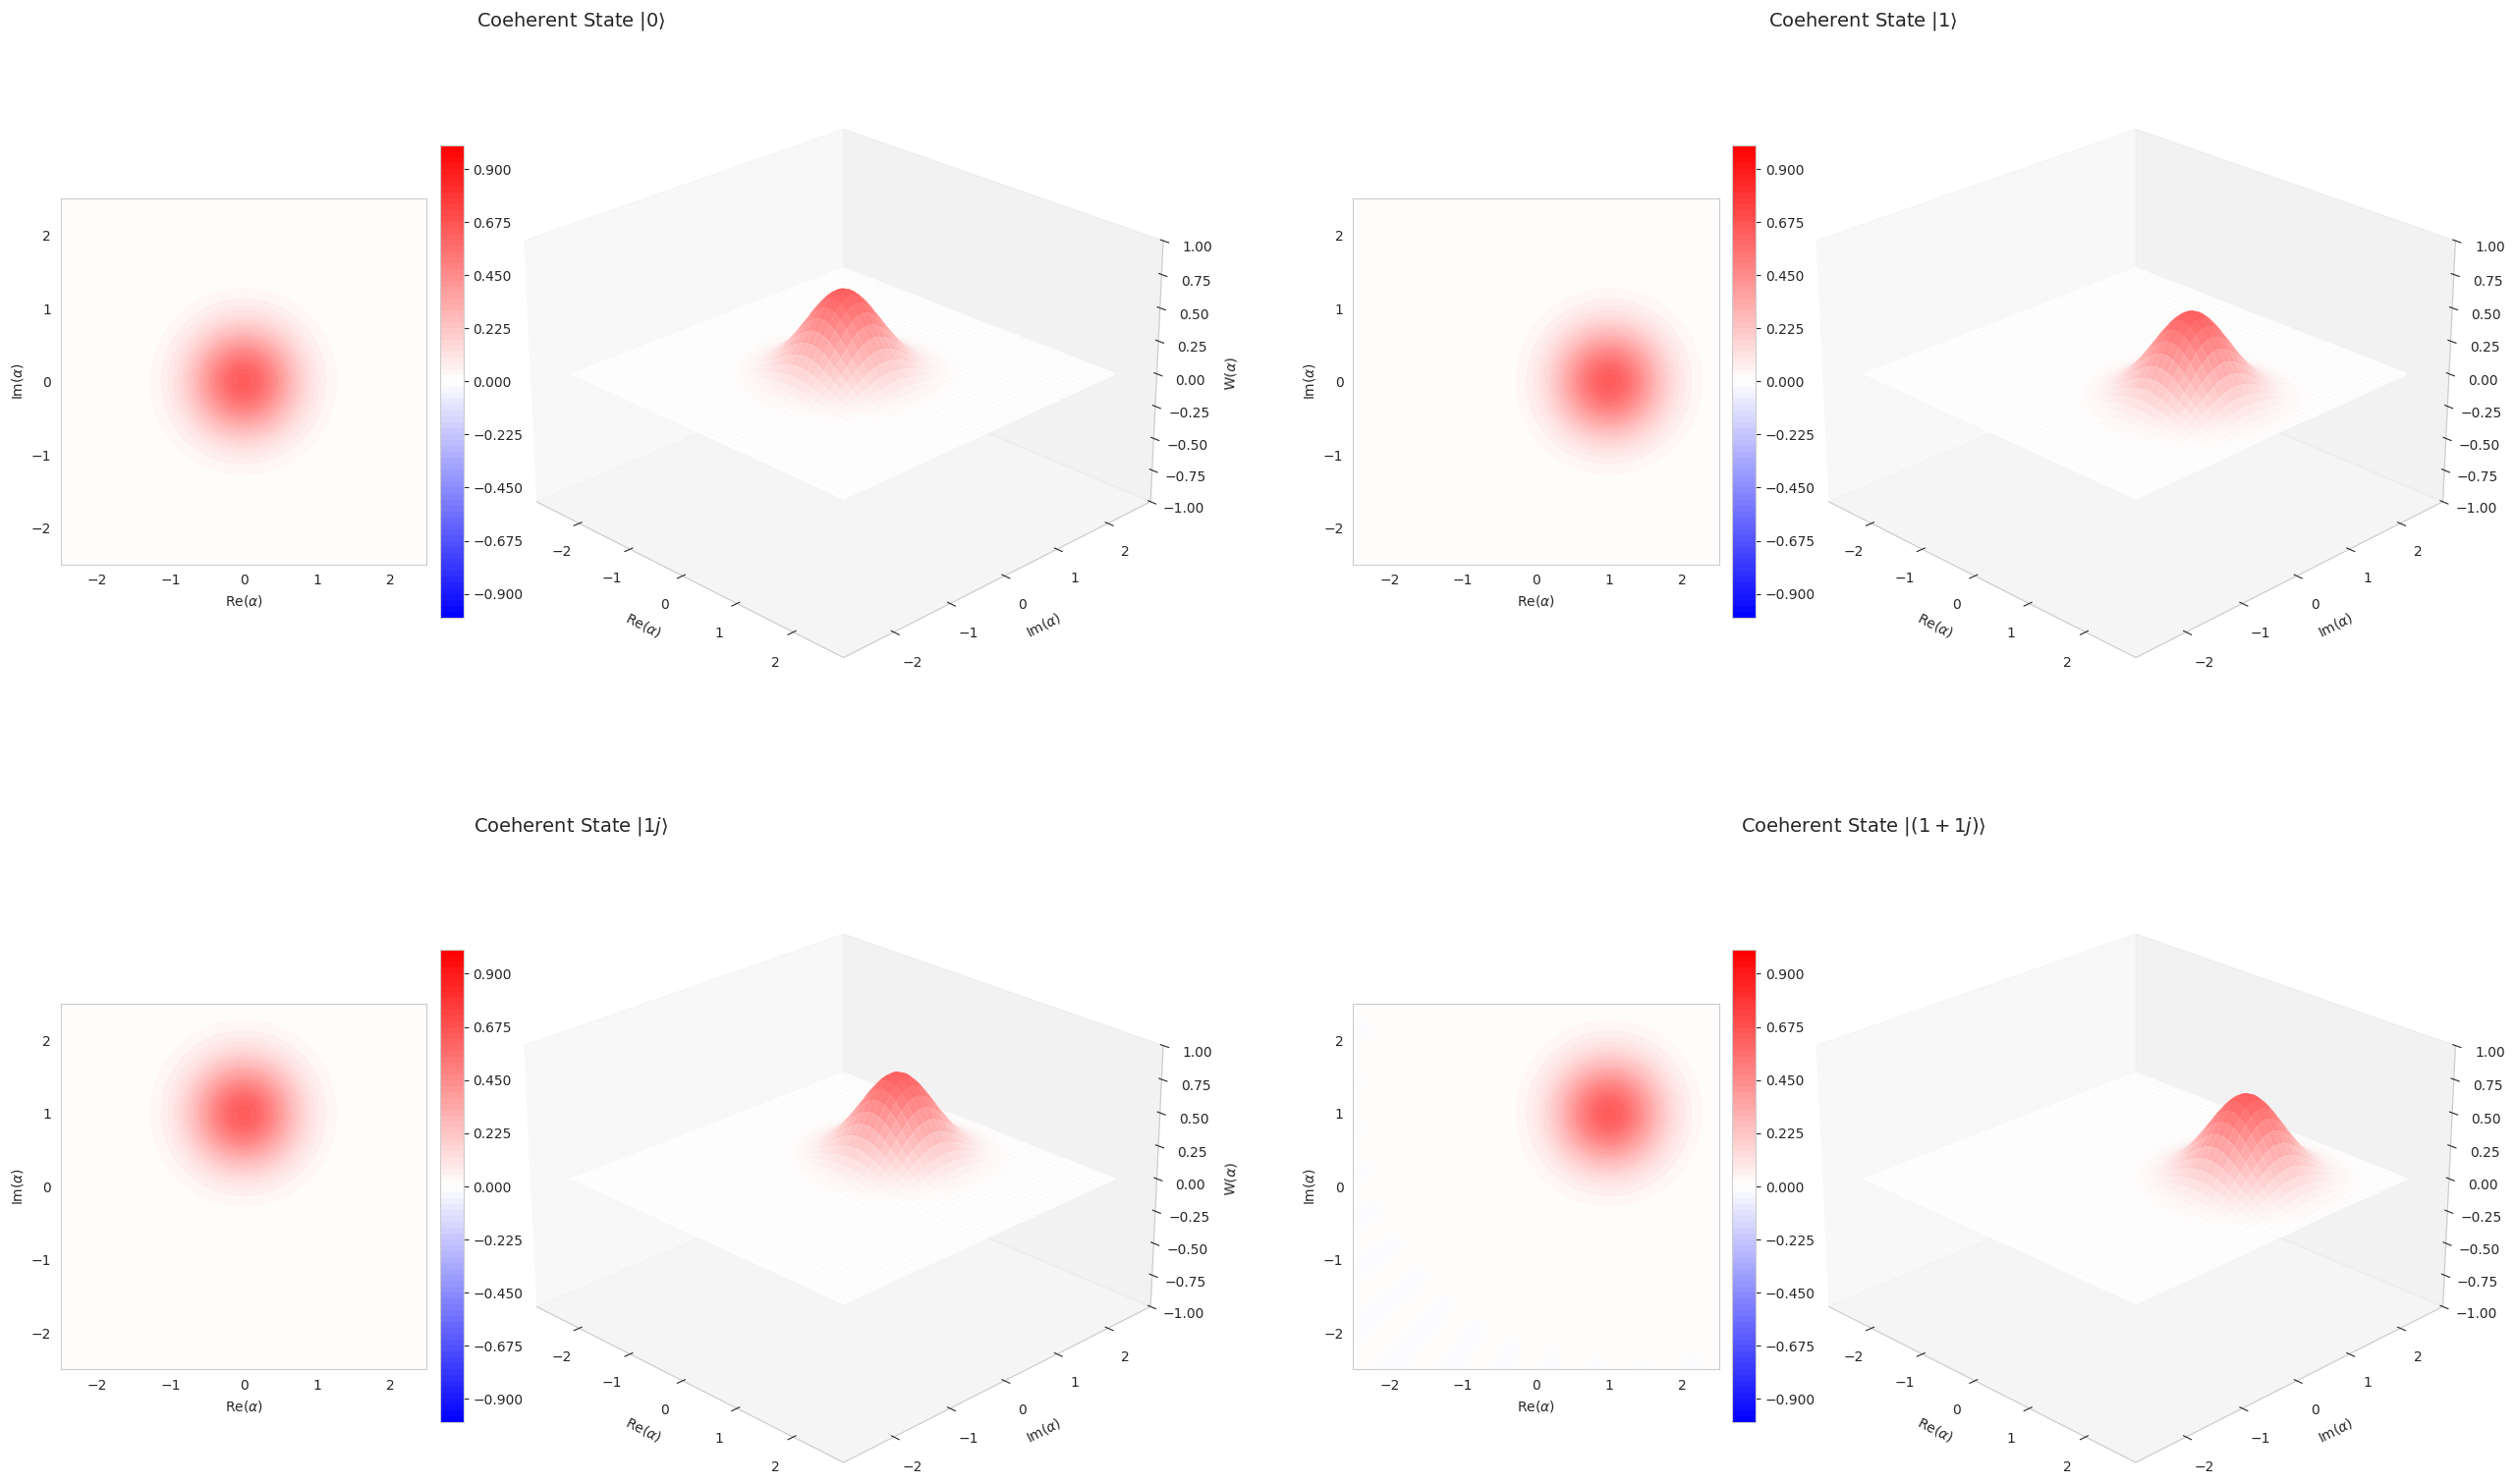

In [83]:
N=25

Alphas = [0, 1, 1j, 1+1j]
fig = plt.figure(figsize=(27, 16))

subfigs = fig.subfigures(2, 2, wspace=-0.05, hspace=0.05)

levels = np.linspace(-1, 1, 81)
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

xvec = np.linspace(-2.5, 2.5, 100)
pvec = np.linspace(-2.5, 2.5, 100)
X, Y = np.meshgrid(xvec, pvec)


for i, subfig in enumerate(subfigs.flat):
  Psi = qp.coherent(N, Alphas[i])

  W = qp.wigner(Psi, xvec, pvec, g=2)


  subfig.suptitle(rf"Coeherent State $ |{Alphas[i]} \rangle $", fontsize=14)

  sub = subfig.add_gridspec(1, 2,width_ratios=[1, 1.25], wspace=0.1)

  ax1 = subfig.add_subplot(sub[0, 0], aspect='equal')
  cont = ax1.contourf(xvec, pvec, W, levels=levels, cmap="bwr", norm = norm)
  subfig.colorbar(cont, ax=ax1, shrink=0.8, aspect=20, pad=0.03)

  ax1.set_xlabel(r'Re($\alpha$)')
  ax1.set_ylabel(r'Im($\alpha$)')


  ax2 = subfig.add_subplot(sub[0, 1], projection='3d')

  surf = ax2.plot_surface(X, Y, W, cmap ="bwr", linewidth = 0, norm=norm, antialiased=True , rstride=2, cstride=2)

  ax2.set_xlabel(r'Re($\alpha$)')
  ax2.set_ylabel(r'Im($\alpha$)')
  ax2.set_zlabel(r'W($\alpha$)')

  ax2.set_zlim3d(-1, 1)
  ax2.grid(False)
  ax2.set_box_aspect((1, 1, 0.65), zoom=1.2)
  ax2.view_init(elev=25, azim=-45)


plt.show()

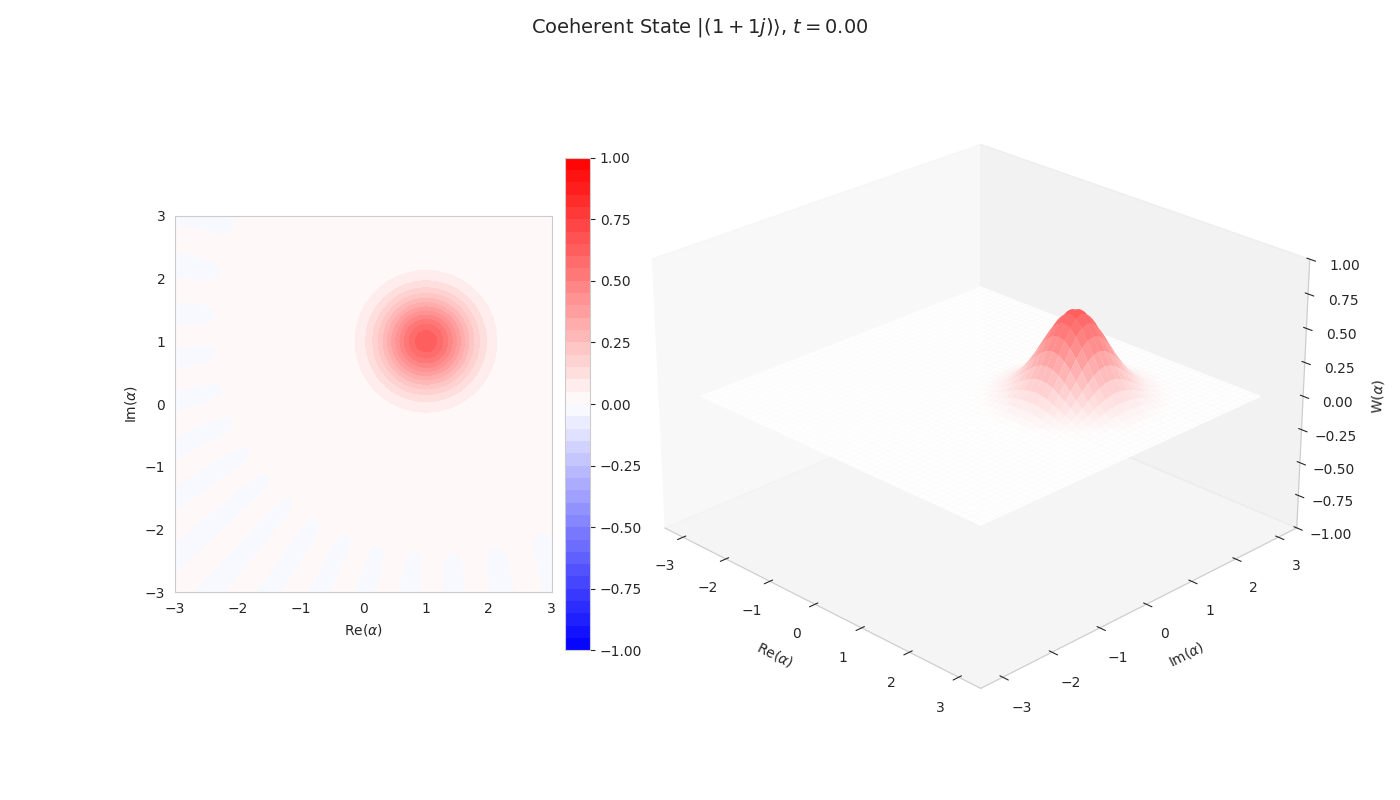

In [107]:
N=25

alpha = 1 +1j #We study the evolution with time of the coherent state |1 +i>
Psi_0 = qp.coherent(N, alpha)

fig = plt.figure(figsize=(14, 8))

levels = np.linspace(-1, 1, 41)
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

xvec = np.linspace(-3, 3, 100)
pvec = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(xvec, pvec)

sub = fig.add_gridspec(1, 2,width_ratios=[1, 1.25], wspace=0.1)
ax1 = fig.add_subplot(sub[0, 0], aspect='equal')
ax2 = fig.add_subplot(sub[0, 1], projection='3d')

cont = ax1.contourf(xvec, pvec, qp.wigner(Psi_0, xvec, pvec, g = 2), levels=levels, cmap="bwr", norm = norm)
fig.colorbar(cont, ax=ax1, shrink=0.8, aspect=20, pad=0.03)


Num_frame = 60
T=np.linspace(0, 2*np.pi, Num_frame)

omega = 1
H = omega * qp.create(N) * qp.destroy(N) #Free Evolution Hamiltonian
Results = qp.mesolve(H, Psi_0, T)



def update(frame_index):
  ax1.clear()
  ax2.clear()

  Time = T[frame_index]

  W = qp.wigner(Results.states[frame_index], xvec, pvec, g = 2)

  fig.suptitle(rf"Coeherent State $ |{alpha} \rangle $, $t = {Time:.2f}$", fontsize=14)


  cont = ax1.contourf(xvec, pvec, W, levels=levels, cmap="bwr", norm = norm)


  ax1.set_xlabel(r'Re($\alpha$)')
  ax1.set_ylabel(r'Im($\alpha$)')


  surf = ax2.plot_surface(X, Y, W, cmap ="bwr", linewidth = 0, norm=norm, antialiased=True , rstride=2, cstride=2)

  ax2.set_xlabel(r'Re($\alpha$)')
  ax2.set_ylabel(r'Im($\alpha$)')
  ax2.set_zlabel(r'W($\alpha$)')

  ax2.set_zlim3d(-1, 1)
  ax2.grid(False)
  ax2.set_box_aspect((1, 1, 0.65), zoom=1.2)
  ax2.view_init(elev=25, azim=-45)


FuncAnimation(fig, update, Num_frame).save('Coherent_Evolution.gif', writer='pillow')

plt.close()
Image('Coherent_Evolution.gif')

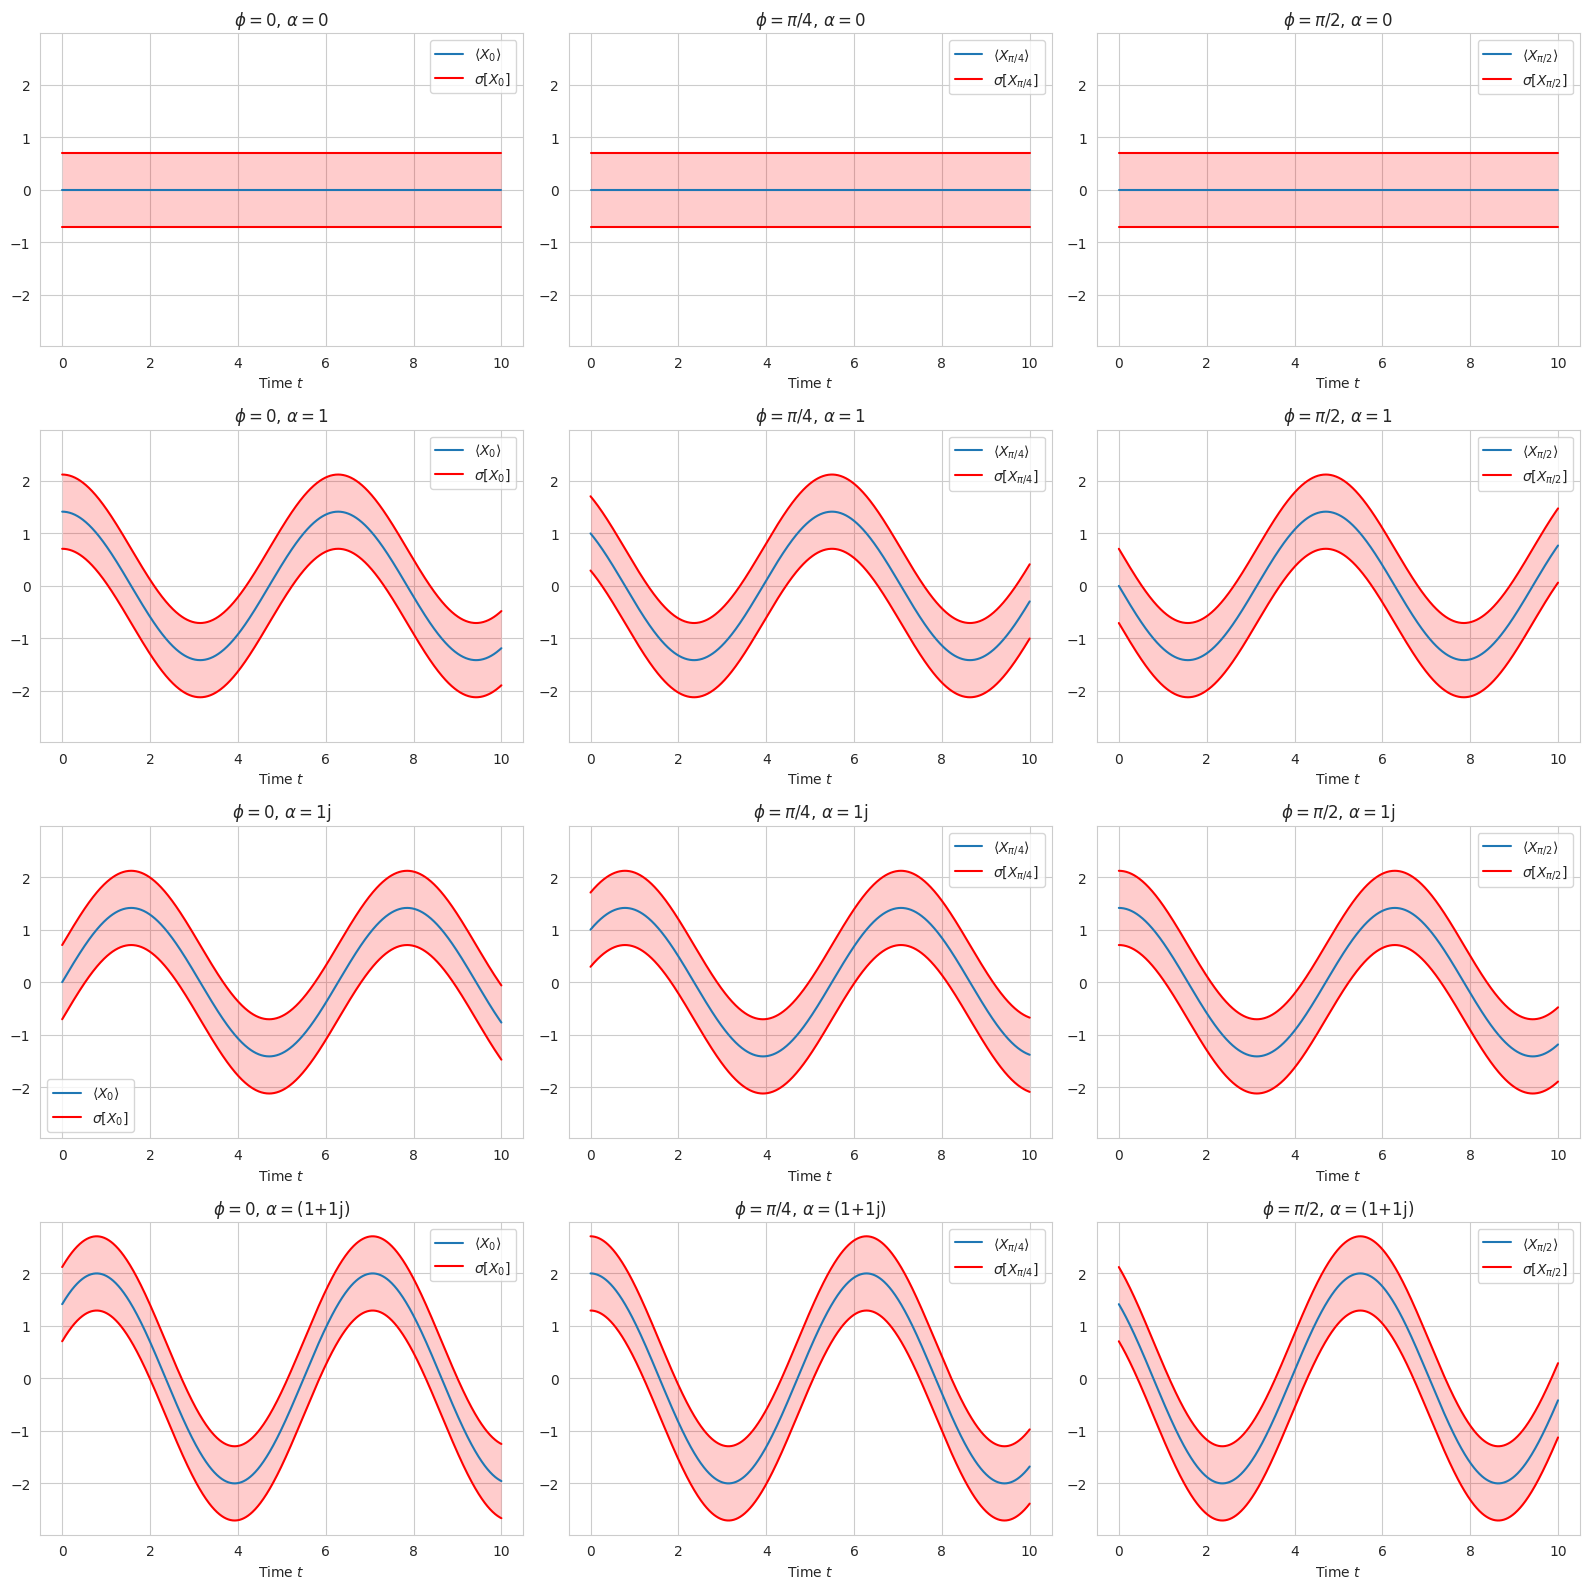

In [76]:
N=25
H_free = qp.create(N)*qp.destroy(N) + 1/2


alphas = [0, 1, 1j, 1+1j]
Phis = [0, np.pi/4, np.pi/2]
Angles = ["0", r"{\pi/4}" ,r"{\pi/2}"]

plt.figure(figsize=(16, 16))

T=np.linspace(0, 10, 1000)

X_AVG = np.zeros((len(alphas), len(Phis), len(T)))
DEVX = np.zeros((len(alphas), len(Phis), len(T)))

c = 1

for j, alpha in enumerate(alphas):
  for i, Phi in enumerate(Phis):



    X_phi = (qp.create(N)*np.exp(Phi*1j)+qp.destroy(N)*np.exp(-Phi*1j))/(np.sqrt(2))
    X_phi_sq = X_phi**2

    Psi_0 = qp.coherent(N, alpha)

    Results = qp.mesolve(H_free, Psi_0, T, e_ops=[X_phi, X_phi_sq])

    X_avg = Results.expect[0]
    X_avg_sq = Results.expect[1]
    VarX = Results.expect[1] - Results.expect[0]**2
    DevStdX = np.sqrt(VarX)

    X_AVG[j, i] = X_avg
    DEVX[j, i] = DevStdX



Xmax = np.maximum((X_AVG + DEVX).max(), (X_AVG - DEVX).max())

if(Xmax > 0):
  Xmax*=1.1
if(Xmax < 0):
  Xmax*=0.9


Xmin = np.minimum((X_AVG + DEVX).min(), (X_AVG - DEVX).min())

if(Xmin > 0):
  Xmin*=0.9
if(Xmin < 0):
  Xmin*=1.1

for j in range(len(alphas)):
  for i in range(len(Phis)):
    plt.subplot(len(alphas), len(Phis), c)
    c+=1
    plt.title(rf"$\phi = {Angles[i]:s}$, $\alpha = ${alphas[j]}")

    plt.plot(T, X_AVG[j, i], label=rf"$ \langle X_{Angles[i]:s} \rangle $")
    plt.plot(T, X_AVG[j, i] + DEVX[j, i], label=rf"$\sigma [X_{Angles[i]:s}]$", color='red')
    plt.plot(T, X_AVG[j, i] - DEVX[j, i], color='red')

    plt.fill_between(T, X_AVG[j, i] - DEVX[j, i], X_AVG[j, i] + DEVX[j, i], facecolor='red', alpha=0.2)

    plt.xlabel(r"Time $t$")

    plt.ylim(Xmin, Xmax)
    plt.legend()



plt.tight_layout()
plt.show()

##Squeezed States

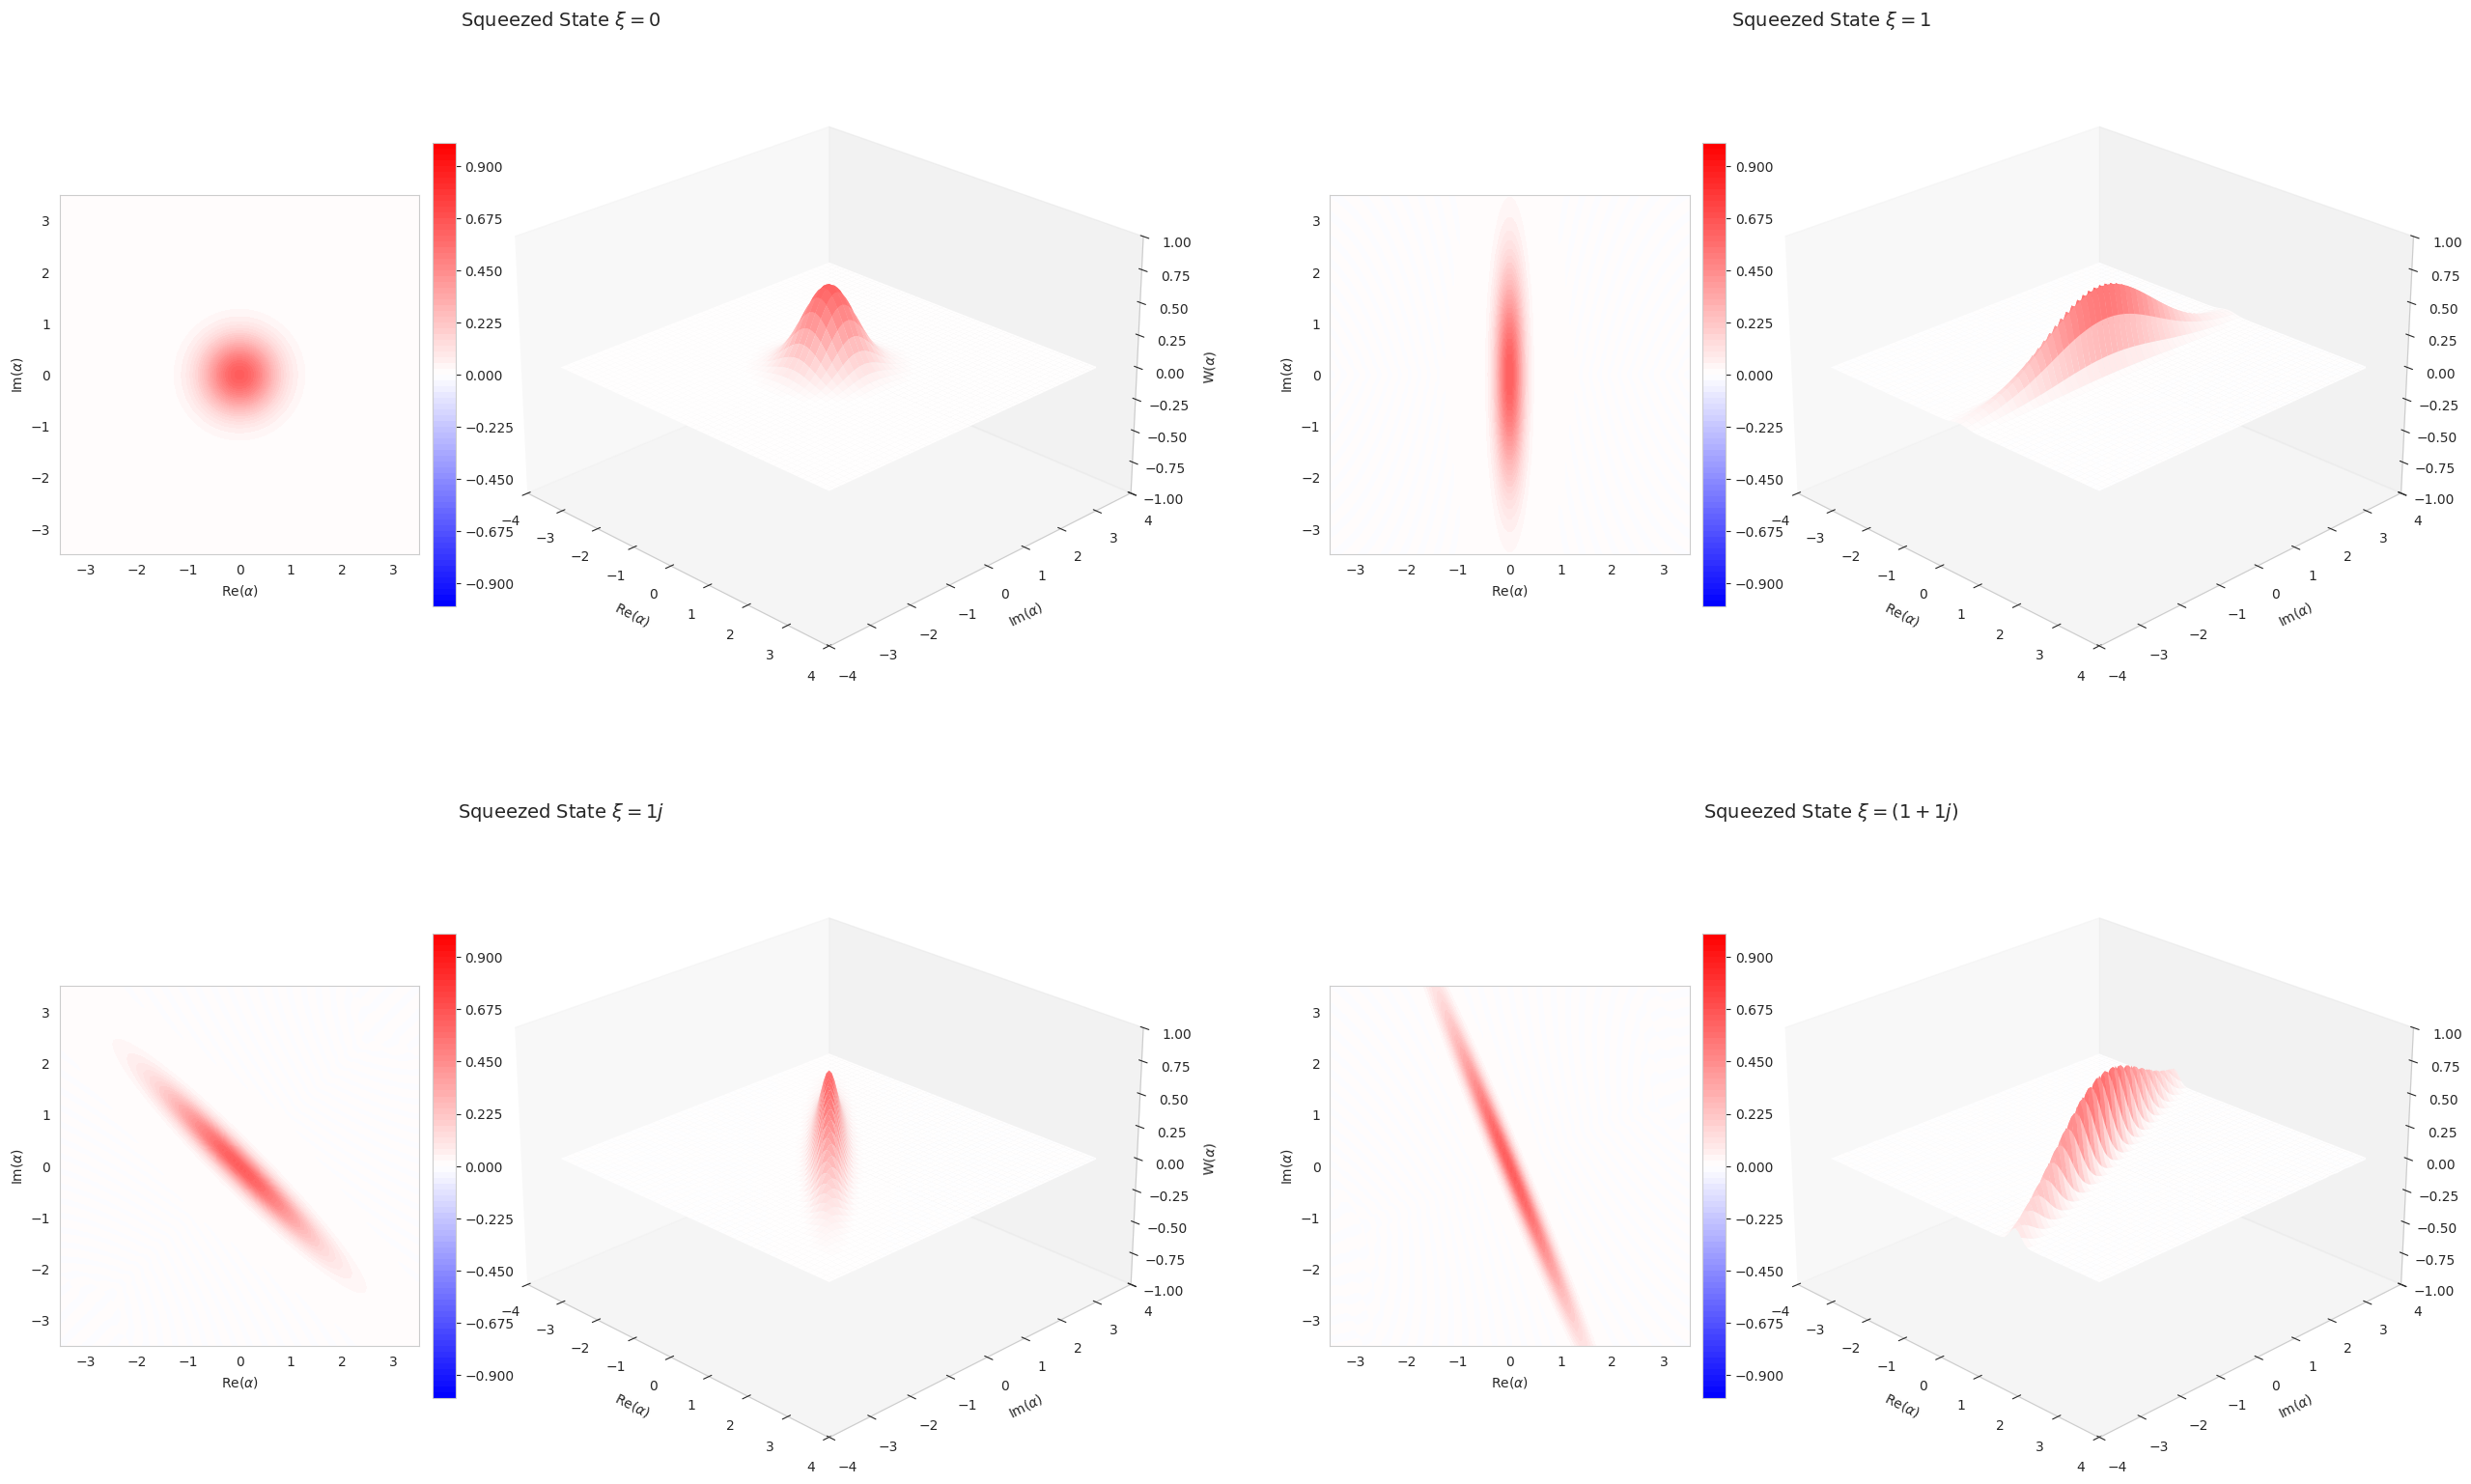

In [89]:
N=80

Xis = [0, 1, 1j, 1+1j]
fig = plt.figure(figsize=(27, 16))

subfigs = fig.subfigures(2, 2, wspace=-0.05, hspace=0.05)

levels = np.linspace(-1, 1, 81)
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

xvec = np.linspace(-3.5, 3.5, 100)
pvec = np.linspace(-3.5, 3.5, 100)
X, Y = np.meshgrid(xvec, pvec)


for i, subfig in enumerate(subfigs.flat):
  Psi = qp.squeeze(N, Xis[i])*qp.fock(N, 0)

  W = qp.wigner(Psi, xvec, pvec, g=2)


  subfig.suptitle(rf"Squeezed State $ \xi = {Xis[i]}$", fontsize=14)

  sub = subfig.add_gridspec(1, 2,width_ratios=[1, 1.25], wspace=0.1)

  ax1 = subfig.add_subplot(sub[0, 0], aspect='equal')
  cont = ax1.contourf(xvec, pvec, W, levels=levels, cmap="bwr", norm = norm)
  subfig.colorbar(cont, ax=ax1, shrink=0.8, aspect=20, pad=0.03)

  ax1.set_xlabel(r'Re($\alpha$)')
  ax1.set_ylabel(r'Im($\alpha$)')


  ax2 = subfig.add_subplot(sub[0, 1], projection='3d')

  surf = ax2.plot_surface(X, Y, W, cmap ="bwr", linewidth = 0, norm=norm, antialiased=True , rstride=2, cstride=2)

  ax2.set_xlabel(r'Re($\alpha$)')
  ax2.set_ylabel(r'Im($\alpha$)')
  ax2.set_zlabel(r'W($\alpha$)')

  ax2.set_zlim3d(-1, 1)
  ax2.grid(False)
  ax2.set_box_aspect((1, 1, 0.65), zoom=1.2)
  ax2.view_init(elev=25, azim=-45)


plt.show()

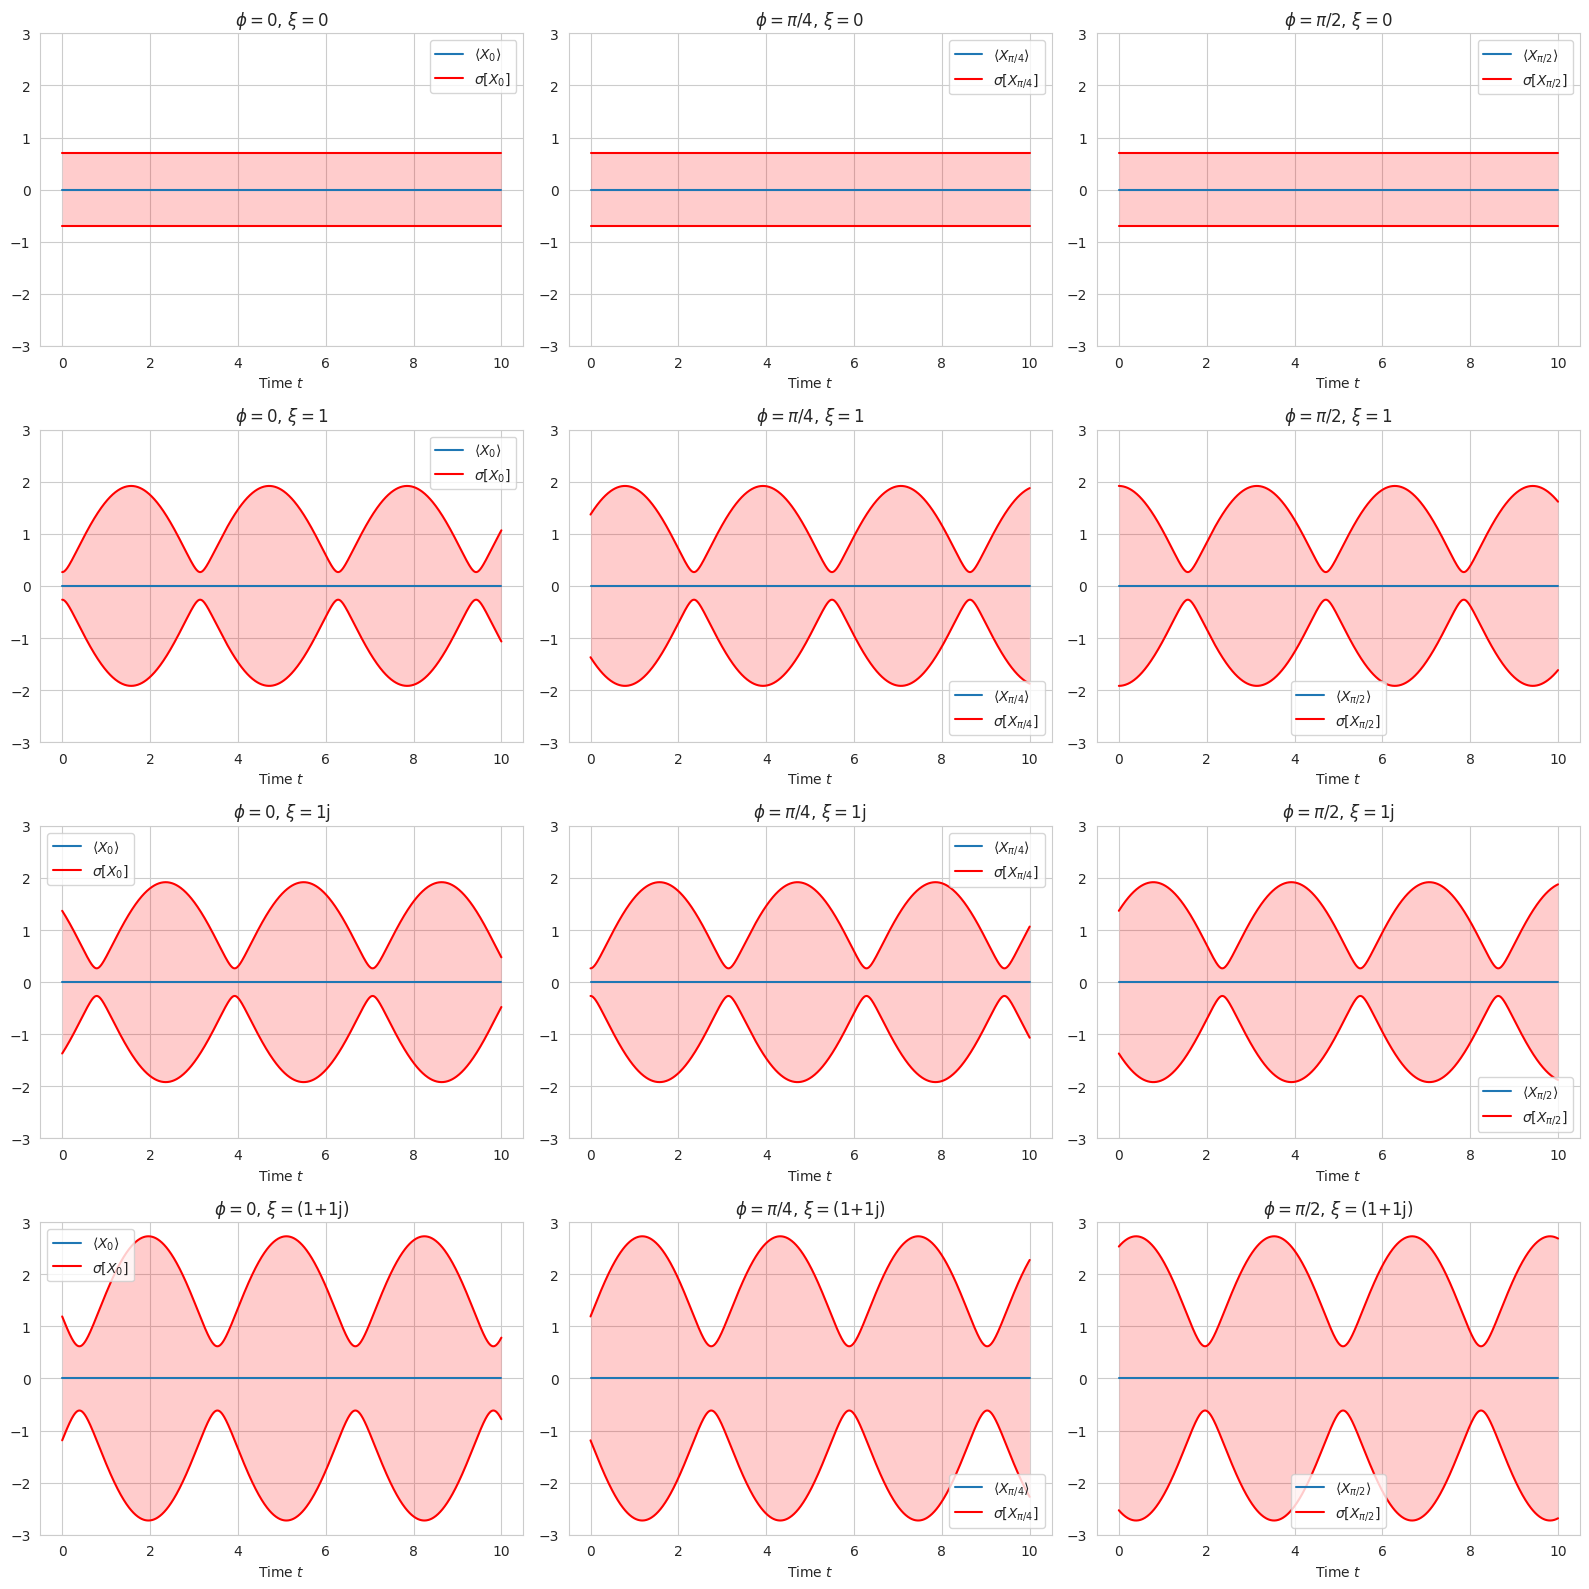

In [77]:
N=25
H_free = qp.create(N)*qp.destroy(N) + 1/2


Xis = [0, 1, 1j, 1+1j]
Phis = [0, np.pi/4, np.pi/2]
Angles = ["0", r"{\pi/4}" ,r"{\pi/2}"]

plt.figure(figsize=(16, 16))

T=np.linspace(0, 10, 1000)

X_AVG = np.zeros((len(Xis), len(Phis), len(T)))
DEVX = np.zeros((len(Xis), len(Phis), len(T)))

c = 1

for j, Xi in enumerate(Xis):
  for i, Phi in enumerate(Phis):



    X_phi = (qp.create(N)*np.exp(Phi*1j)+qp.destroy(N)*np.exp(-Phi*1j))/(np.sqrt(2))
    X_phi_sq = X_phi**2

    Psi_0 = qp.squeeze(N, Xi)*qp.fock(N, 0)

    Results = qp.mesolve(H_free, Psi_0, T, e_ops=[X_phi, X_phi_sq])

    X_avg = Results.expect[0]
    X_avg_sq = Results.expect[1]
    VarX = Results.expect[1] - Results.expect[0]**2
    DevStdX = np.sqrt(VarX)

    X_AVG[j, i] = X_avg
    DEVX[j, i] = DevStdX



Xmax = np.maximum((X_AVG + DEVX).max(), (X_AVG - DEVX).max())

if(Xmax > 0):
  Xmax*=1.1
if(Xmax < 0):
  Xmax*=0.9


Xmin = np.minimum((X_AVG + DEVX).min(), (X_AVG - DEVX).min())

if(Xmin > 0):
  Xmin*=0.9
if(Xmin < 0):
  Xmin*=1.1

for j in range(len(Xis)):
  for i in range(len(Phis)):
    plt.subplot(len(Xis), len(Phis), c)
    c+=1
    plt.title(rf"$\phi = {Angles[i]:s}$, $\xi = ${Xis[j]}")

    plt.plot(T, X_AVG[j, i], label=rf"$ \langle X_{Angles[i]:s} \rangle $")
    plt.plot(T, X_AVG[j, i] + DEVX[j, i], label=rf"$\sigma [X_{Angles[i]:s}]$", color='red')
    plt.plot(T, X_AVG[j, i] - DEVX[j, i], color='red')

    plt.fill_between(T, X_AVG[j, i] - DEVX[j, i], X_AVG[j, i] + DEVX[j, i], facecolor='red', alpha=0.2)

    plt.xlabel(r"Time $t$")

    plt.ylim(Xmin, Xmax)
    plt.legend()



plt.tight_layout()
plt.show()

##Thermal States

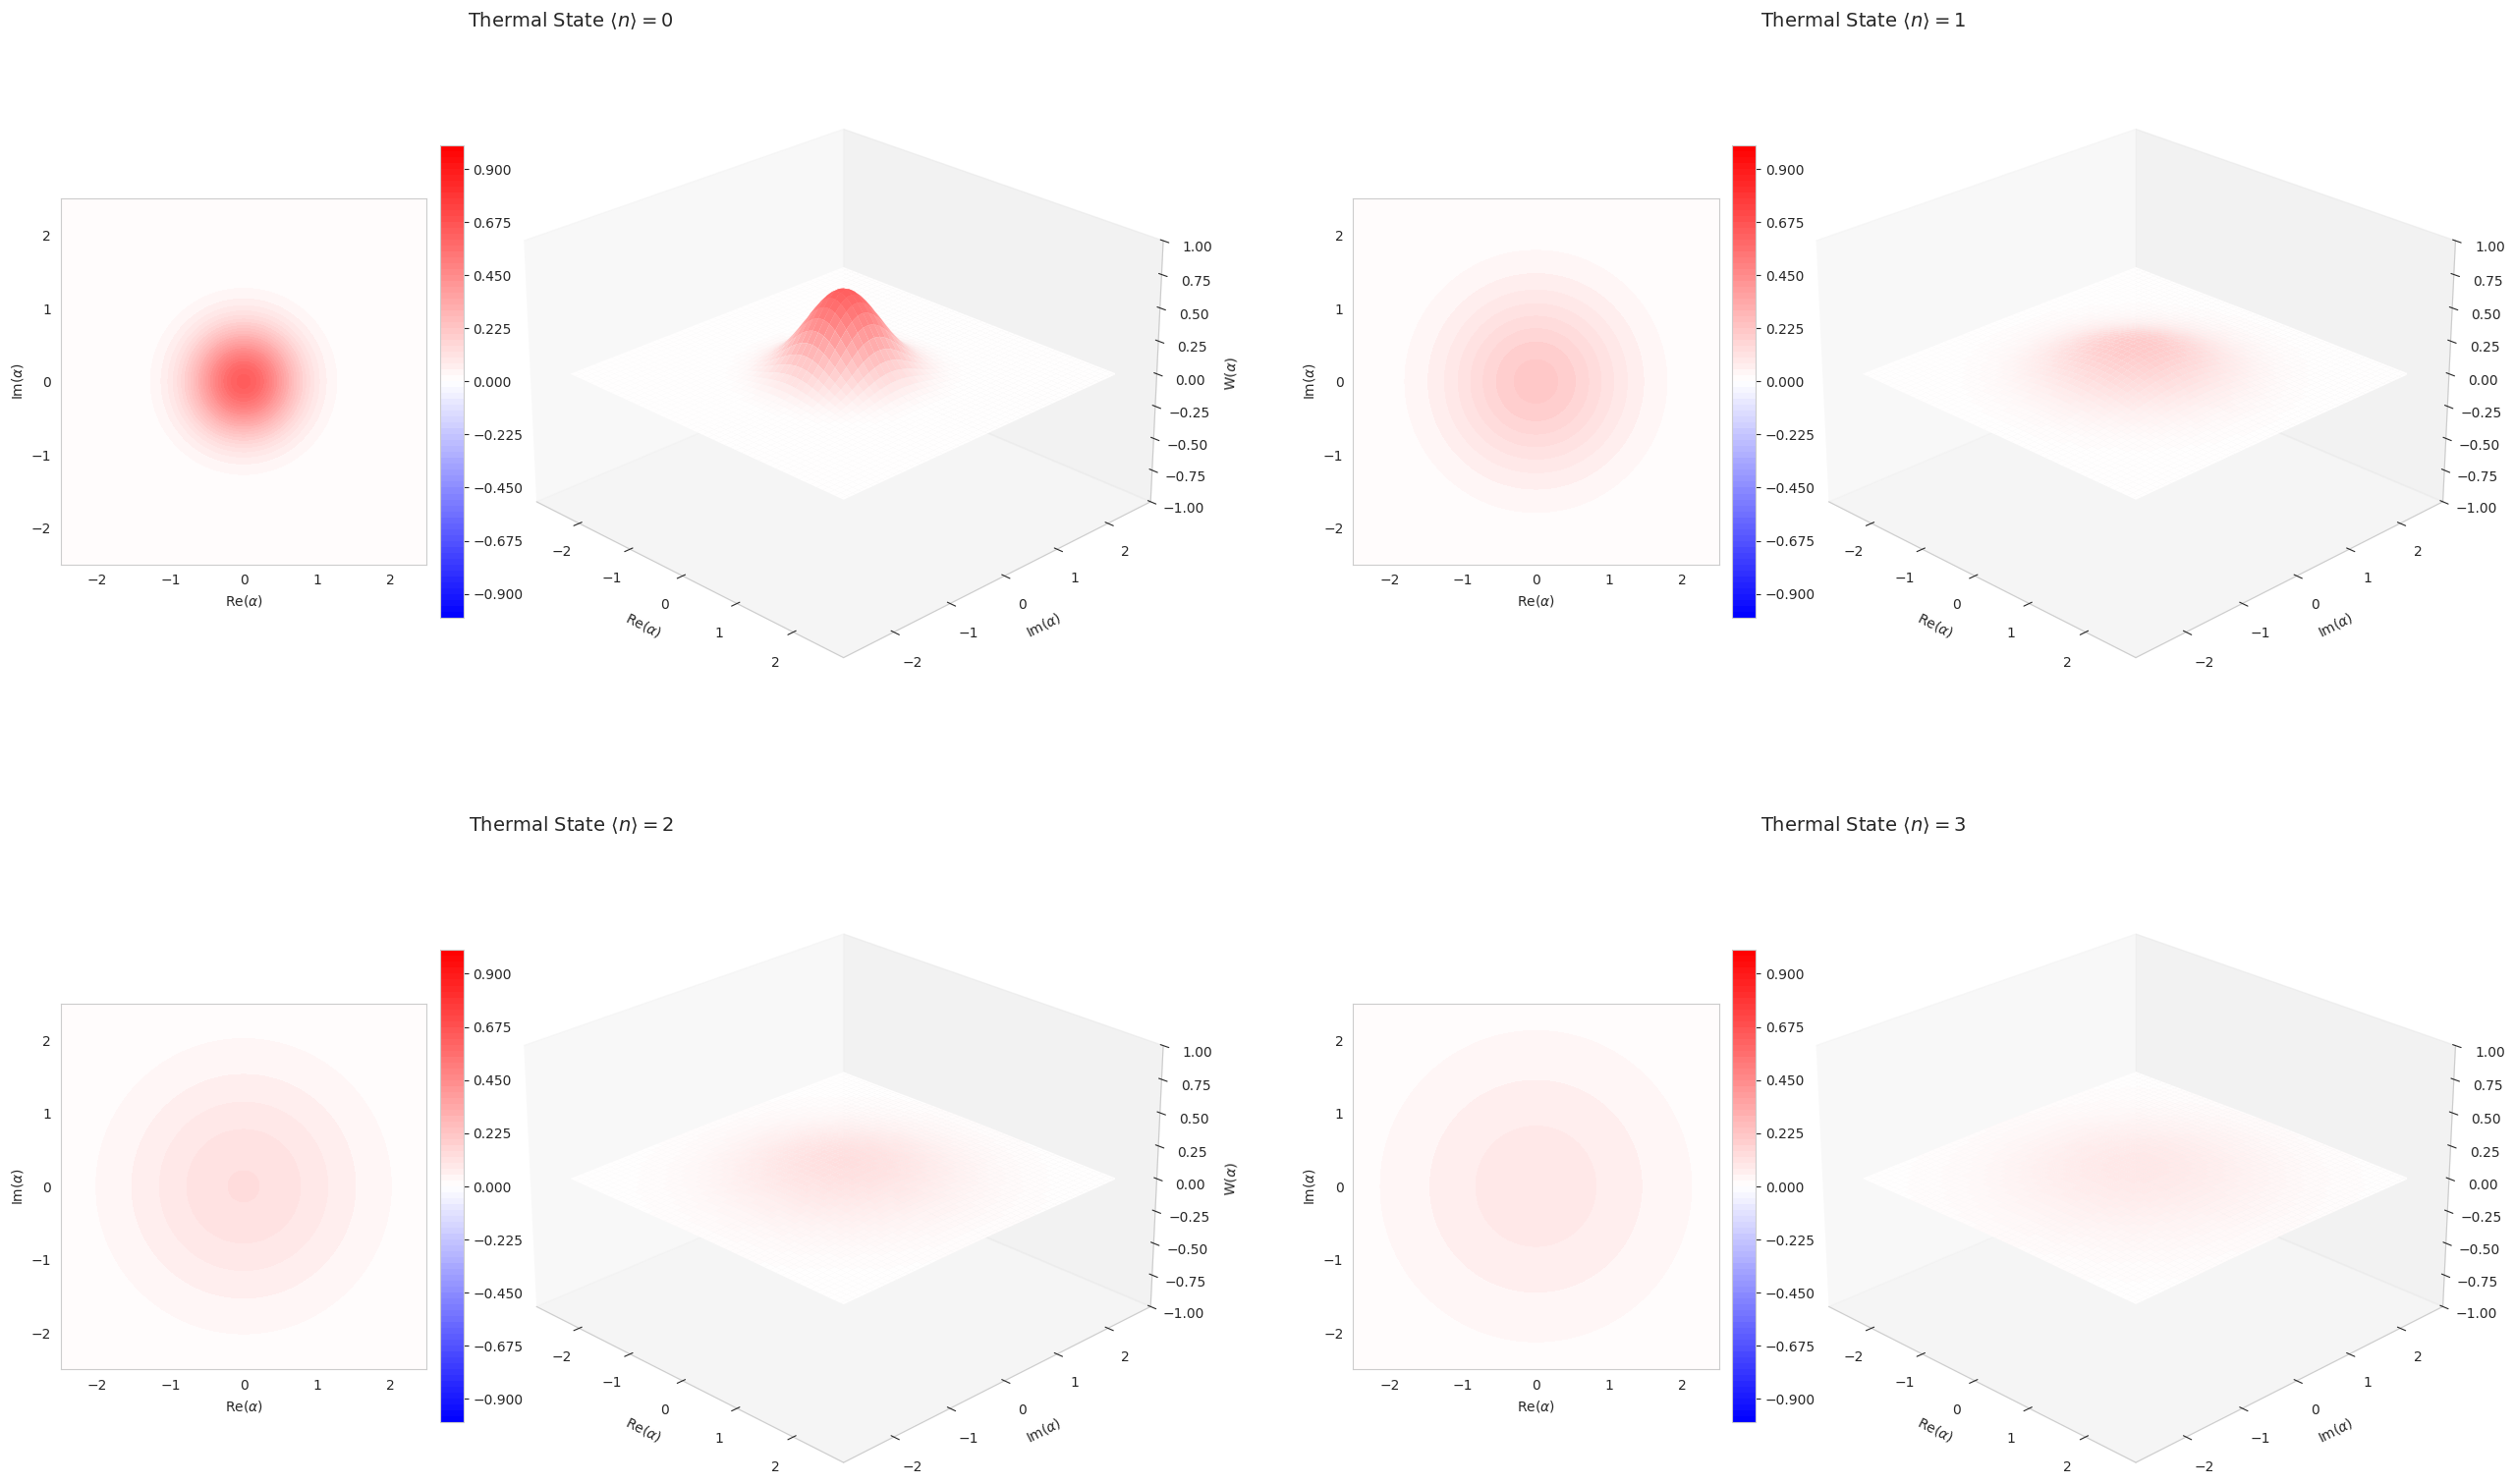

In [90]:
N=25

fig = plt.figure(figsize=(27, 16))

subfigs = fig.subfigures(2, 2, wspace=-0.05, hspace=0.05)

levels = np.linspace(-1, 1, 81)
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

xvec = np.linspace(-2.5, 2.5, 100)
pvec = np.linspace(-2.5, 2.5, 100)
X, Y = np.meshgrid(xvec, pvec)


for i, subfig in enumerate(subfigs.flat):
  Rho = qp.thermal_dm(N, i)

  W = qp.wigner(Rho, xvec, pvec, g=2)


  subfig.suptitle(rf"Thermal State $ \langle n \rangle = {i} $", fontsize=14)

  sub = subfig.add_gridspec(1, 2,width_ratios=[1, 1.25], wspace=0.1)

  ax1 = subfig.add_subplot(sub[0, 0], aspect='equal')
  cont = ax1.contourf(xvec, pvec, W, levels=levels, cmap="bwr", norm = norm)
  subfig.colorbar(cont, ax=ax1, shrink=0.8, aspect=20, pad=0.03)

  ax1.set_xlabel(r'Re($\alpha$)')
  ax1.set_ylabel(r'Im($\alpha$)')


  ax2 = subfig.add_subplot(sub[0, 1], projection='3d')

  surf = ax2.plot_surface(X, Y, W, cmap ="bwr", linewidth = 0, norm=norm, antialiased=True , rstride=2, cstride=2)

  ax2.set_xlabel(r'Re($\alpha$)')
  ax2.set_ylabel(r'Im($\alpha$)')
  ax2.set_zlabel(r'W($\alpha$)')

  ax2.set_zlim3d(-1, 1)
  ax2.grid(False)
  ax2.set_box_aspect((1, 1, 0.65), zoom=1.2)
  ax2.view_init(elev=25, azim=-45)


plt.show()

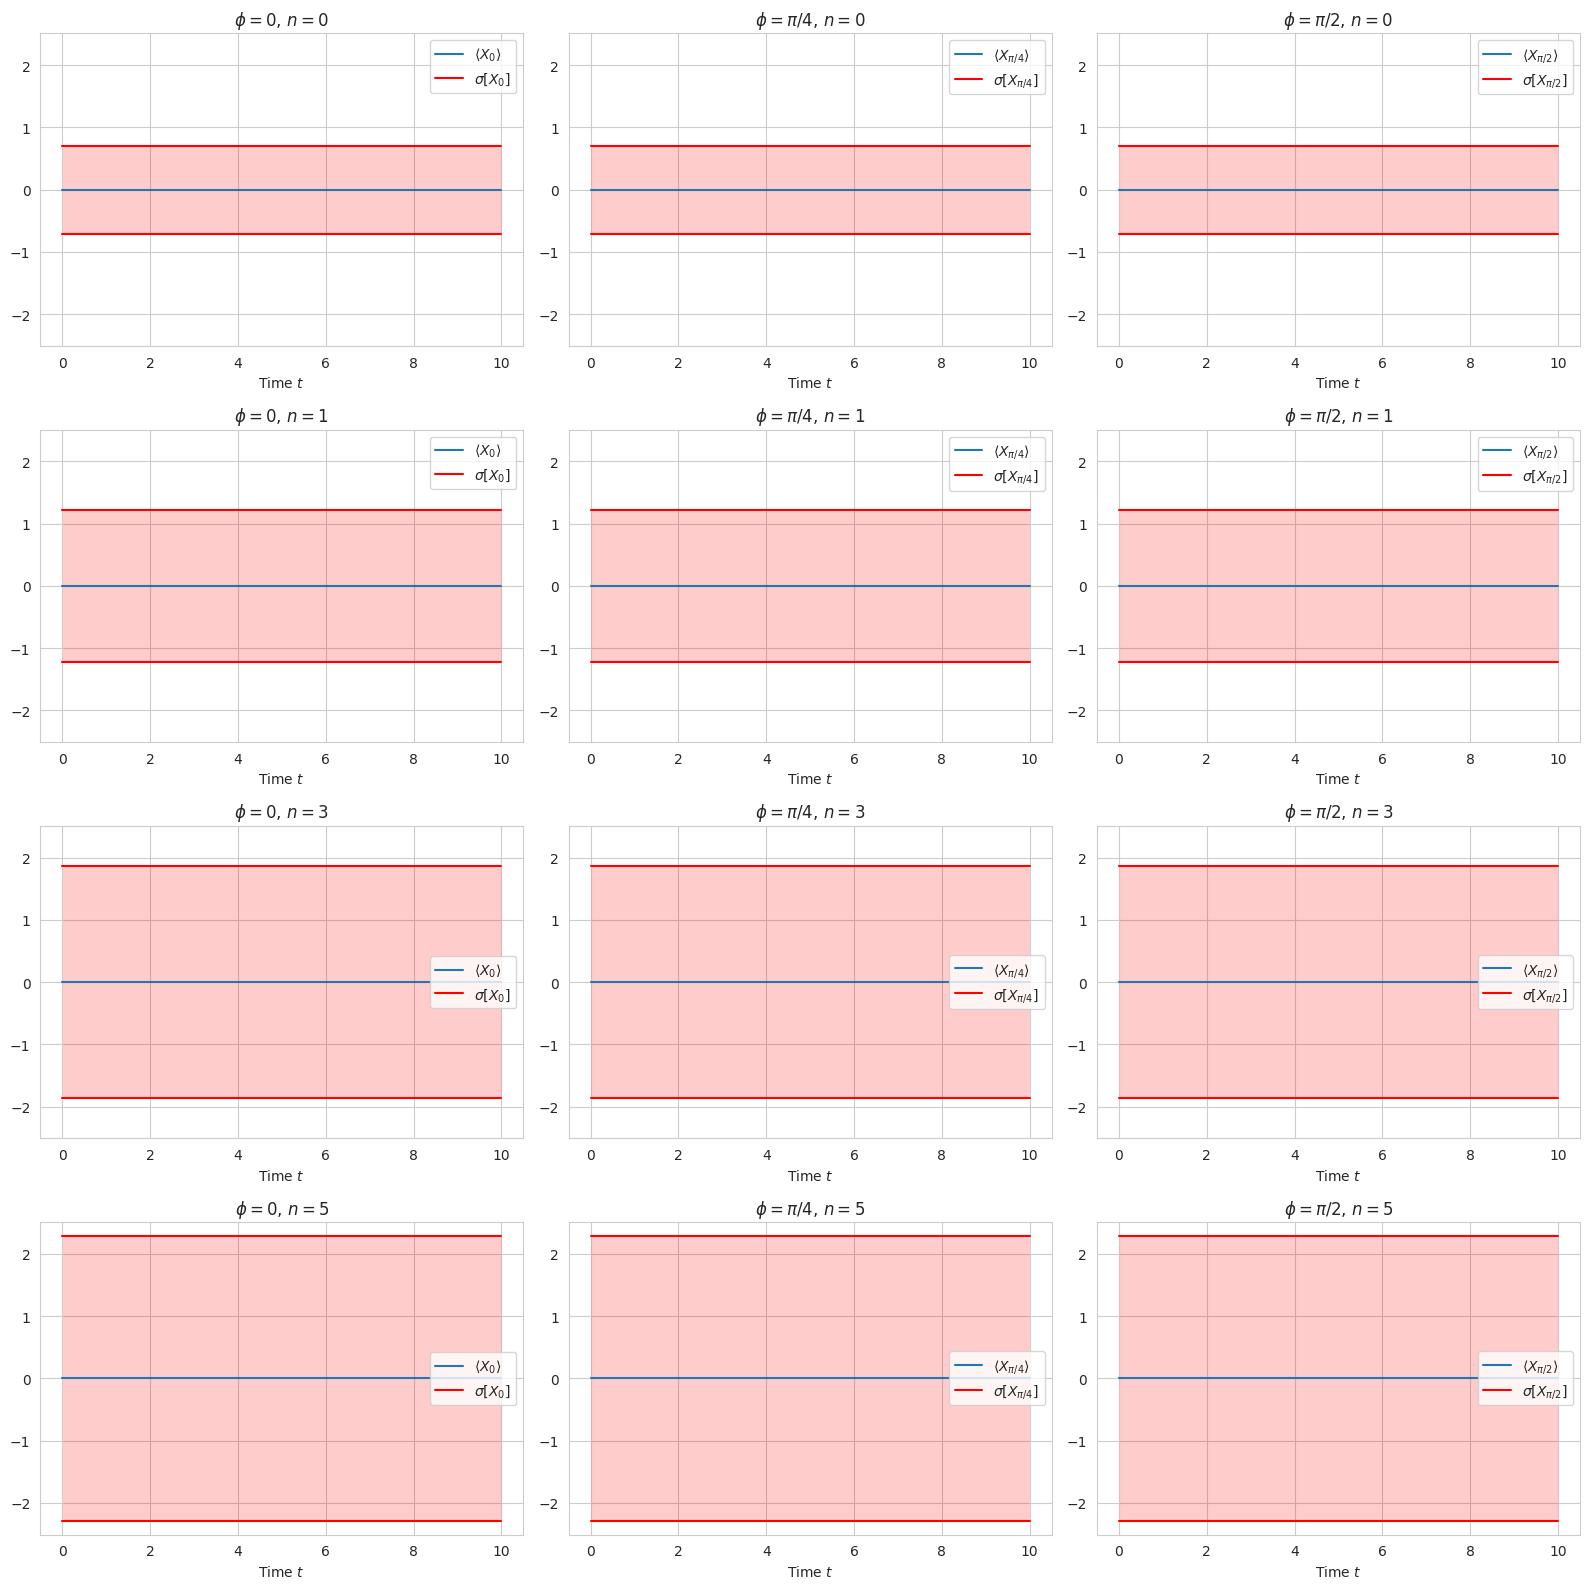

In [79]:
N=25
H_free = qp.create(N)*qp.destroy(N) + 1/2


ns = [0, 1, 3, 5]
Phis = [0, np.pi/4, np.pi/2]
Angles = ["0", r"{\pi/4}" ,r"{\pi/2}"]

plt.figure(figsize=(16, 16))

T=np.linspace(0, 10, 1000)

X_AVG = np.zeros((len(ns), len(Phis), len(T)))
DEVX = np.zeros((len(ns), len(Phis), len(T)))

c = 1

for j, n in enumerate(ns):
  for i, Phi in enumerate(Phis):



    X_phi = (qp.create(N)*np.exp(Phi*1j)+qp.destroy(N)*np.exp(-Phi*1j))/(np.sqrt(2))
    X_phi_sq = X_phi**2

    Rho_0 = qp.thermal_dm(N, n)


    Results = qp.mesolve(H_free, Rho_0, T, e_ops=[X_phi, X_phi_sq])

    X_avg = Results.expect[0]
    X_avg_sq = Results.expect[1]
    VarX = Results.expect[1] - Results.expect[0]**2
    DevStdX = np.sqrt(VarX)

    X_AVG[j, i] = X_avg
    DEVX[j, i] = DevStdX



Xmax = np.maximum((X_AVG + DEVX).max(), (X_AVG - DEVX).max())

if(Xmax > 0):
  Xmax*=1.1
if(Xmax < 0):
  Xmax*=0.9


Xmin = np.minimum((X_AVG + DEVX).min(), (X_AVG - DEVX).min())

if(Xmin > 0):
  Xmin*=0.9
if(Xmin < 0):
  Xmin*=1.1

for j in range(len(ns)):
  for i in range(len(Phis)):
    plt.subplot(len(ns), len(Phis), c)
    c+=1
    plt.title(rf"$\phi = {Angles[i]:s}$, $n = ${ns[j]}")

    plt.plot(T, X_AVG[j, i], label=rf"$ \langle X_{Angles[i]:s} \rangle $")
    plt.plot(T, X_AVG[j, i] + DEVX[j, i], label=rf"$\sigma [X_{Angles[i]:s}]$", color='red')
    plt.plot(T, X_AVG[j, i] - DEVX[j, i], color='red')

    plt.fill_between(T, X_AVG[j, i] - DEVX[j, i], X_AVG[j, i] + DEVX[j, i], facecolor='red', alpha=0.2)

    plt.xlabel(r"Time $t$")

    plt.ylim(Xmin, Xmax)
    plt.legend()



plt.tight_layout()
plt.show()

##Cat States

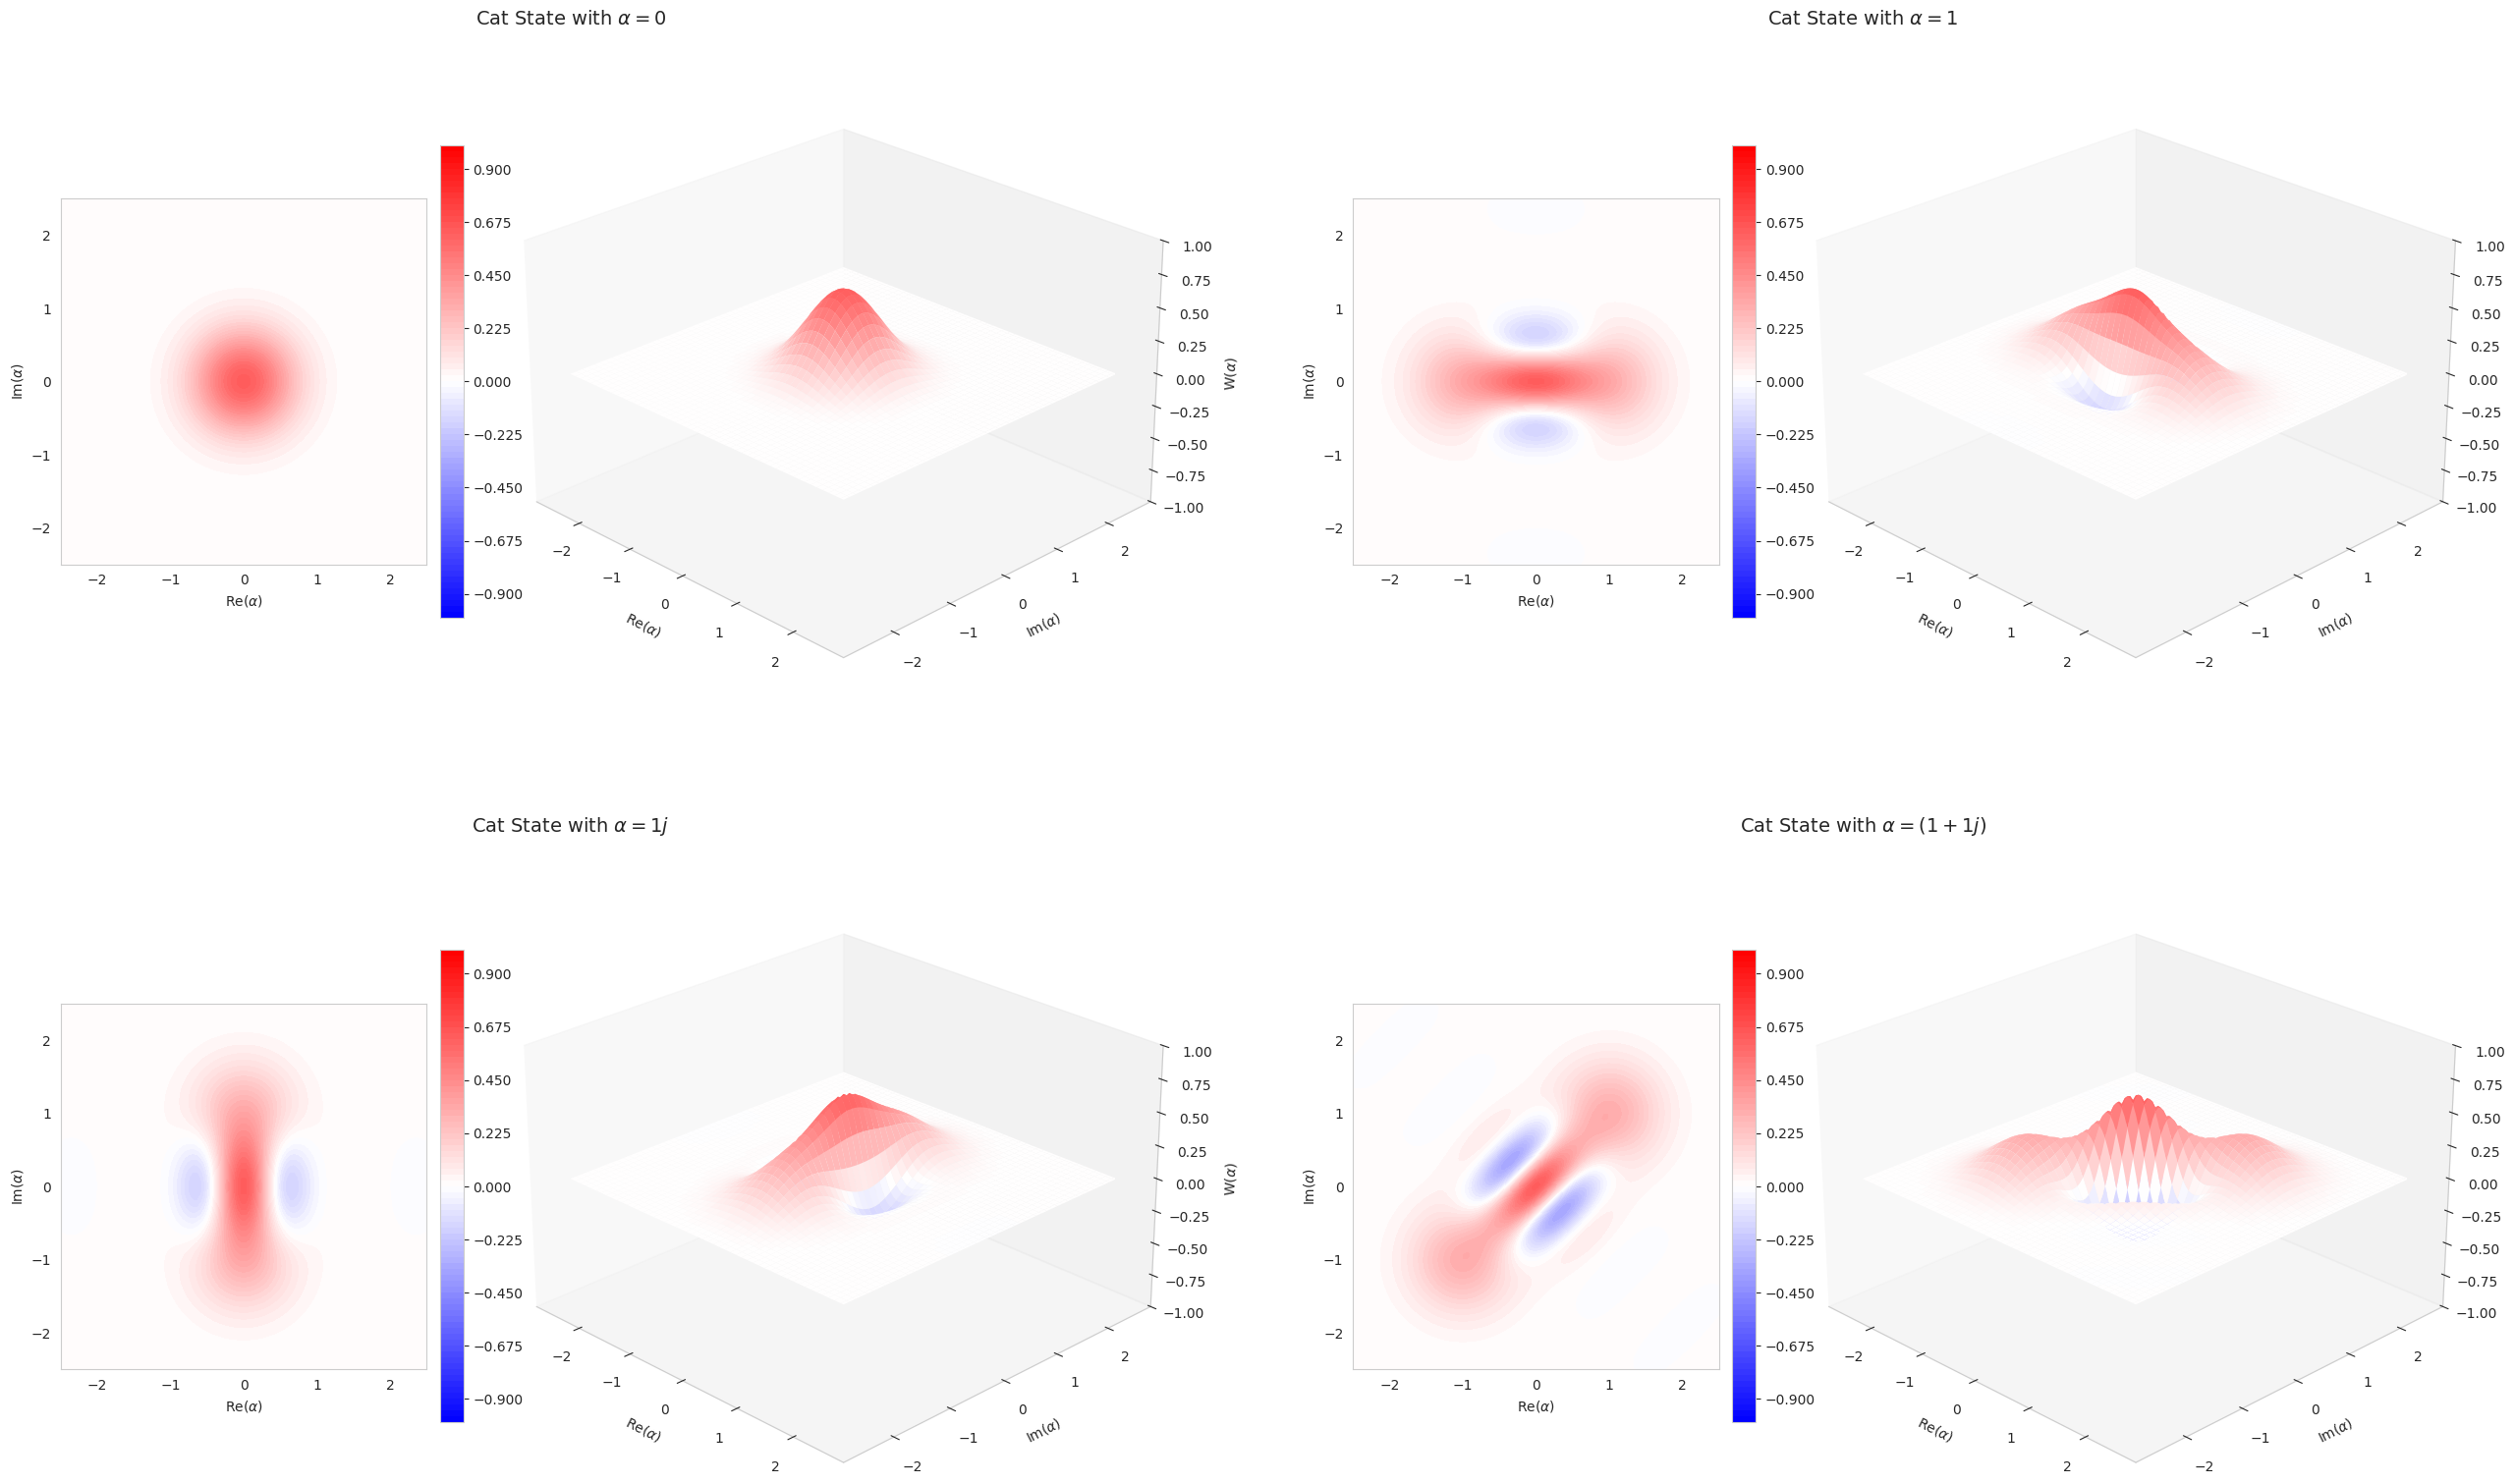

In [92]:
N=25

Alphas = [0, 1, 1j, 1+1j]
fig = plt.figure(figsize=(27, 16))

subfigs = fig.subfigures(2, 2, wspace=-0.05, hspace=0.05)

levels = np.linspace(-1, 1, 81)
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

xvec = np.linspace(-2.5, 2.5, 100)
pvec = np.linspace(-2.5, 2.5, 100)
X, Y = np.meshgrid(xvec, pvec)


for i, subfig in enumerate(subfigs.flat):
  Psi = (qp.coherent(N, Alphas[i])+qp.coherent(N, -Alphas[i])).unit()

  W = qp.wigner(Psi, xvec, pvec, g=2)


  subfig.suptitle(rf"Cat State with $ \alpha = {Alphas[i]} $", fontsize=14)

  sub = subfig.add_gridspec(1, 2,width_ratios=[1, 1.25], wspace=0.1)

  ax1 = subfig.add_subplot(sub[0, 0], aspect='equal')
  cont = ax1.contourf(xvec, pvec, W, levels=levels, cmap="bwr", norm = norm)
  subfig.colorbar(cont, ax=ax1, shrink=0.8, aspect=20, pad=0.03)

  ax1.set_xlabel(r'Re($\alpha$)')
  ax1.set_ylabel(r'Im($\alpha$)')


  ax2 = subfig.add_subplot(sub[0, 1], projection='3d')

  surf = ax2.plot_surface(X, Y, W, cmap ="bwr", linewidth = 0, norm=norm, antialiased=True , rstride=2, cstride=2)

  ax2.set_xlabel(r'Re($\alpha$)')
  ax2.set_ylabel(r'Im($\alpha$)')
  ax2.set_zlabel(r'W($\alpha$)')

  ax2.set_zlim3d(-1, 1)
  ax2.grid(False)
  ax2.set_box_aspect((1, 1, 0.65), zoom=1.2)
  ax2.view_init(elev=25, azim=-45)


plt.show()

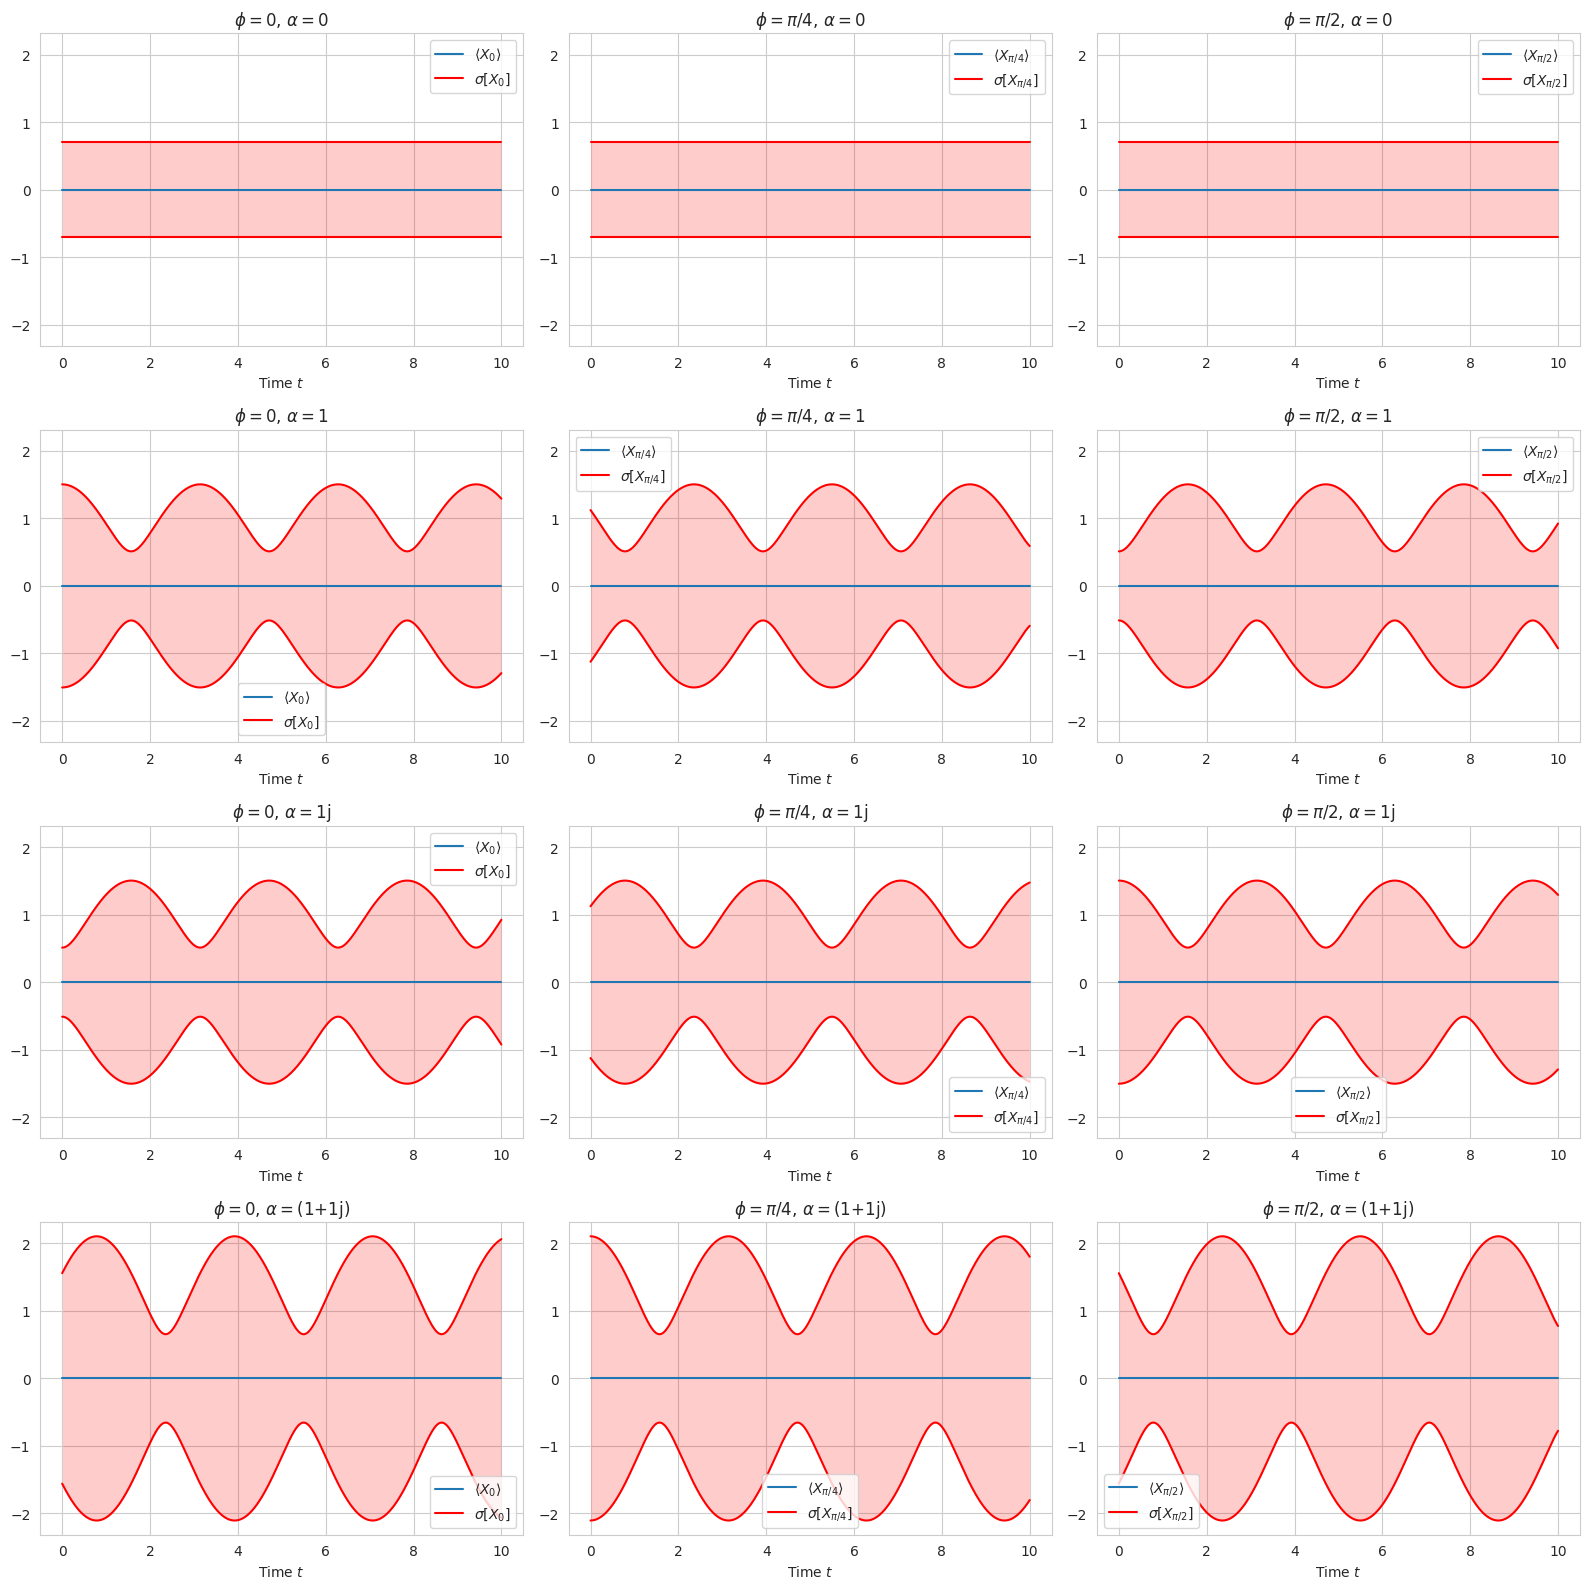

In [81]:
N=25
H_free = qp.create(N)*qp.destroy(N) + 1/2


alphas = [0, 1, 1j, 1+1j]
Phis = [0, np.pi/4, np.pi/2]
Angles = ["0", r"{\pi/4}" ,r"{\pi/2}"]

plt.figure(figsize=(16, 16))

T=np.linspace(0, 10, 1000)

X_AVG = np.zeros((len(alphas), len(Phis), len(T)))
DEVX = np.zeros((len(alphas), len(Phis), len(T)))

c = 1

for j, alpha in enumerate(alphas):
  for i, Phi in enumerate(Phis):



    X_phi = (qp.create(N)*np.exp(Phi*1j)+qp.destroy(N)*np.exp(-Phi*1j))/(np.sqrt(2))
    X_phi_sq = X_phi**2

    Psi_0 = (qp.coherent(N, alpha)+qp.coherent(N, -alpha)).unit()

    Results = qp.mesolve(H_free, Psi_0, T, e_ops=[X_phi, X_phi_sq])

    X_avg = Results.expect[0]
    X_avg_sq = Results.expect[1]
    VarX = Results.expect[1] - Results.expect[0]**2
    DevStdX = np.sqrt(VarX)

    X_AVG[j, i] = X_avg
    DEVX[j, i] = DevStdX



Xmax = np.maximum((X_AVG + DEVX).max(), (X_AVG - DEVX).max())

if(Xmax > 0):
  Xmax*=1.1
if(Xmax < 0):
  Xmax*=0.9


Xmin = np.minimum((X_AVG + DEVX).min(), (X_AVG - DEVX).min())

if(Xmin > 0):
  Xmin*=0.9
if(Xmin < 0):
  Xmin*=1.1

for j in range(len(alphas)):
  for i in range(len(Phis)):
    plt.subplot(len(alphas), len(Phis), c)
    c+=1
    plt.title(rf"$\phi = {Angles[i]:s}$, $\alpha = ${alphas[j]}")

    plt.plot(T, X_AVG[j, i], label=rf"$ \langle X_{Angles[i]:s} \rangle $")
    plt.plot(T, X_AVG[j, i] + DEVX[j, i], label=rf"$\sigma [X_{Angles[i]:s}]$", color='red')
    plt.plot(T, X_AVG[j, i] - DEVX[j, i], color='red')

    plt.fill_between(T, X_AVG[j, i] - DEVX[j, i], X_AVG[j, i] + DEVX[j, i], facecolor='red', alpha=0.2)

    plt.xlabel(r"Time $t$")

    plt.ylim(Xmin, Xmax)
    plt.legend()



plt.tight_layout()
plt.show()